In [1]:
import signac
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymser
from matplotlib.backends.backend_pdf import PdfPages

from utils.molec_class_files import esolvs
from Build_GPs.utils.signac import get_signac_results, save_signac_results
from Build_GPs.utils.id_new_samples import new_samples_vle, find_pareto, new_samples_ld, check_mse_10
from Build_GPs.utils.models import get_best_models
from Build_GPs.utils.plot import plot_gp_examples
import pickle

from fffit.fffit.utils import values_real_to_scaled, values_scaled_to_real

2026-05-27 16:45:44.414714: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779914744.437192  478350 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779914744.443319  478350 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779914744.459485  478350 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779914744.459502  478350 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779914744.459504  478350 computation_placer.cc:177] computation placer alr

/scratch365/mcarlozo/ES-FFO/Opt_ES/utilsOpt/opt_atom_types.py:167: UserWarning: No gp data found for ACN. Many functions will not work without GP Data
  warnings.warn(
/scratch365/mcarlozo/ES-FFO/Opt_ES/utilsOpt/opt_atom_types.py:167: UserWarning: No gp data found for THF. Many functions will not work without GP Data
  warnings.warn(
/scratch365/mcarlozo/ES-FFO/Opt_ES/utilsOpt/opt_atom_types.py:167: UserWarning: No gp data found for DCM. Many functions will not work without GP Data
  warnings.warn(
/scratch365/mcarlozo/ES-FFO/Opt_ES/utilsOpt/opt_atom_types.py:167: UserWarning: No gp data found for ACN. Many functions will not work without GP Data
  warnings.warn(
/scratch365/mcarlozo/ES-FFO/Opt_ES/utilsOpt/opt_atom_types.py:167: UserWarning: No gp data found for THF. Many functions will not work without GP Data
  warnings.warn(
/scratch365/mcarlozo/ES-FFO/Opt_ES/utilsOpt/opt_atom_types.py:167: UserWarning: No gp data found for DCM. Many functions will not work without GP Data
  warning

OSError: [Errno 30] Read-only file system: 'GP_vs_FF_MAPD_comparison.png'

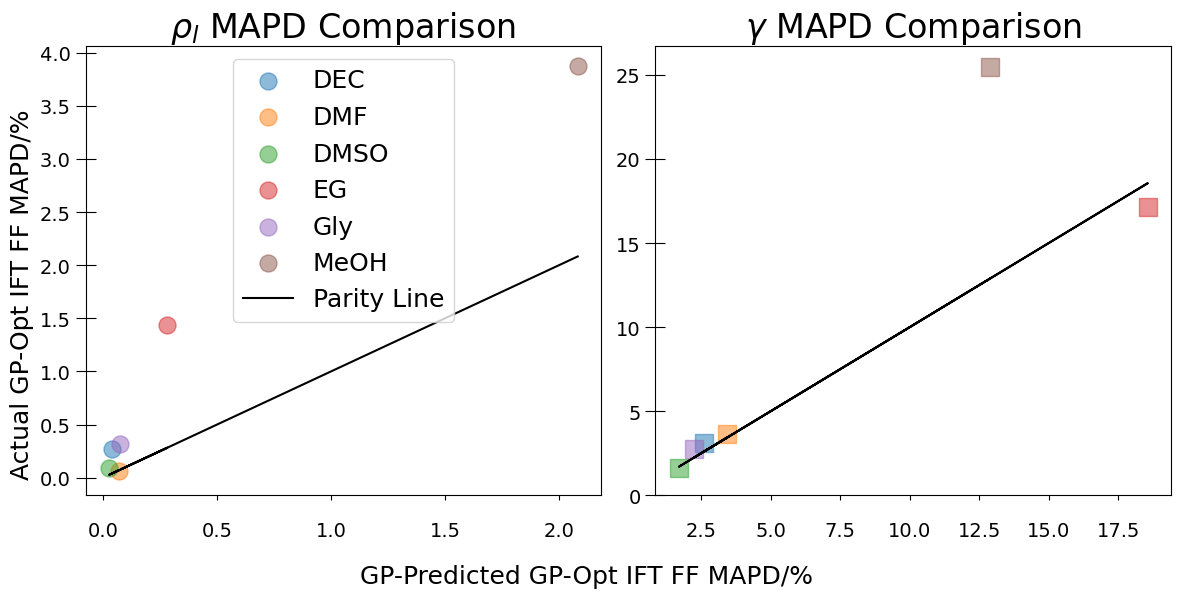

In [ ]:
#Compare GP Prediction Accuracy to MAPD of final FF model
import os
from Build_GPs.utils.models import get_exp_data, loo_model_perform
mol_names = ["DEC", "DMF", "DMSO", "EG", "Gly", "MeOH"] 
molec_dict = esolvs.make_dict(mol_names)

os.chdir("/scratch365/mcarlozo/ES-FFO/Opt_ES")
from utilsOpt import opt_atom_types
#For each of the 6 solvents
data_dict = []
#Load GP models
max_mapd = 0
for mol_name in mol_names:
    at_num = 0 
    setup = opt_atom_types.Problem_Setup([mol_name], at_num, "ExpVal")
    # Set parameter set of interest (in this case get the best parameter set)
    x_label = "best_set"
    all_molec_dir = setup.use_dir_name
    GPs = setup.all_gp_dict[mol_name]
    for prop_name in ["liq_density", "surf_tens"]:
        GP_model = GPs[f"sim_{prop_name}"]
        mol_data = molec_dict[mol_name]

        #get the MAPD of final FF model predictions on test set
        #load from Opt_ES/analysis/at_00/MeOH/ExpVal/opt_res/ms_val_opt/error_data.csv
        error_data = pd.read_csv(f"{setup.use_dir_name}/ms_val_opt/error_data.csv")
        ff_mapd = error_data[f'mapd_{prop_name}'].max()
        exp_data, property_bounds, property_name = get_exp_data(mol_data, prop_name)
        # print(f"{mol_name} {prop_name} GP MAPD: {GP_mapd}, FF MAPD: {ff_mapd}")

        #Calculate MAPD of GP model predictions on test set
        #Get x_data and y_data for test set
        # x_test = f"../Build_GPs/analysis/{mol_name}/vle_iters/iter-1/train_test_sets/sim_{prop_name}_x_test.csv"
        # y_test = f"../Build_GPs/analysis/{mol_name}/vle_iters/iter-1/train_test_sets/sim_{prop_name}_y_test.csv"
        # x_data = pd.read_csv(x_test, index_col=0)
        # y_data = pd.read_csv(y_test, index_col=0)
        # __, GP_mapd = loo_model_perform({prop_name: GP_model}, x_data.values, y_data.values, property_bounds)

        #Or get x and y data from the org parameter sets and property values used to train the GP model
        #Get parameter sets and property values for best parameter set
        ms_data = pd.read_csv(f"{setup.use_dir_name}/ms_val_opt/ms_data.csv")
        param_bounds, param_names = setup.get_param_bnds_names()
        first_param_name = param_names[0]
        last_param_name = param_names[-1]
        real_best_set = ms_data.loc[:, first_param_name:last_param_name].values
        real_temp = ms_data.loc[:, "temperature"].values
        real_prop = ms_data.loc[:, f"sim_{prop_name}"].values
        #scale the parameter sets to be between 0 and 1 using the parameter bounds
        scaled_best_set = values_real_to_scaled(real_best_set, param_bounds)
        temperature_bounds = mol_data.temperature_bounds(f"expt_{prop_name}")
        scaled_temp = values_real_to_scaled(real_temp, temperature_bounds)
        scaled_prop = values_real_to_scaled(real_prop, property_bounds)
        x_data = np.hstack((scaled_best_set, scaled_temp))
        y_data = scaled_prop
        
        #Calculate MAPD of GP model predictions on the parameter sets and property values used to train the GP model
        __, GP_mapd = loo_model_perform({prop_name: GP_model}, x_data, y_data, property_bounds)
        
        data_dict.append([mol_name, prop_name, property_name, GP_mapd, ff_mapd])
        if np.maximum(GP_mapd, ff_mapd) > max_mapd:
            max_mapd = np.maximum(GP_mapd, ff_mapd)
    
#Plot the results on a scatter plot with MAPD of GP on x-axis and MAPD of FF on y-axis. 2 subplots for each property
data_df = pd.DataFrame(data_dict, columns=["Molecule", "Property", "Property Name", "GP_MAPD", "FF_MAPD"])
fig, axes = plt.subplots(1, 2, figsize=(12,6))
for i, property_name in enumerate(data_df["Property Name"].unique()):
    label_type = "o" if i == 0 else "s"
    prop_data = data_df[data_df["Property Name"] == property_name]
    colors = plt.cm.tab10.colors
    for j in range(len(prop_data)):
        #If the molecule is not Glycerol, plot it as a point, if it is Glycerol, skip the next color
        # if prop_data["Molecule"].iloc[j] != "Gly":
        axes[i].scatter(prop_data["GP_MAPD"].iloc[j], prop_data["FF_MAPD"].iloc[j], 
                        label=prop_data["Molecule"].iloc[j], 
                        color=colors[j % len(colors)], marker=label_type, s=150, alpha = 0.5)
    axes[i].plot(prop_data["GP_MAPD"], prop_data["GP_MAPD"], color="black", label = "Parity Line")
    # axes[i].set_ylabel("GP-Opt IFT FF Simulated MAPD", fontsize = 18)
    axes[i].set_title(f"{property_name.split('/')[0]} MAPD Comparison", fontsize = 24)
    if i == 1:
        axes[i].set_ylim(0, max_mapd*1.05)
        # axes[i].set_xlabel(f"GP-Predicted MAPD", fontsize = 18)
    else:
        axes[i].legend(loc="upper center", fontsize = 18)
    axes[i].tick_params("y", direction="inout", which="both", length=7)
    axes[i].tick_params("y", which="major", length=14)
    axes[i].tick_params("x", pad=15)
    #Increase font size of ticks    
    axes[i].tick_params(axis='both', which='major', labelsize=14)
fig.supylabel('Actual GP-Opt IFT FF MAPD/%', fontsize=18)
fig.supxlabel('GP-Predicted GP-Opt IFT FF MAPD/%', fontsize=18)

plt.tight_layout()

#Save the figure
plt.savefig("GP_FF_MAPD_comparison.png")

In [ ]:
#Check if the simulation seems likely to vaporize/liquidate. 
from scipy.signal import savgol_filter
eq_col_liq = np.loadtxt("Opt_ES/gemc_val/workspace/95dfcb6a0eff27bb28d174d64a8f0c65/Liquid_eq_col_5.csv", delimiter=",")
# When this step happens, at least 200K steps should have been run
#Check if the number of molecules in the liquid box is decreasing on average
steps = np.arange(0, len(eq_col_liq))
print(len(steps))
# Estimate the slope of the number of molecules in the liquid box vs step number
win_len = max(3, int(len(eq_col_liq) * 0.1) | 1)
dydx = savgol_filter(eq_col_liq, window_length=win_len, polyorder=2, deriv=1)
#Count percentage of points with positive slope
pos_slope = np.count_nonzero(dydx > 0)
pct_pos = pos_slope/len(dydx)*100
print(f"Percentage of points with positive slope: {pct_pos:.2f}%")
#if more than 85% of the points have a positive slope, the liquid box is likely to condense (increase vapor box size)
if pct_pos > 85:
    #     #If we've already increased the vapor box once, double the volume
    # if "vap_box_mult" in job.doc.keys():
    #     job.doc.vap_box_mult = round(((job.doc["vap_box_mult"]**3)*2))**(1/3)
    # #Shrink vapor box volume by factor of 3
    # else:
    #     job.doc.vap_box_mult = round(2.5**(1/3),3)
    # prod_ready["box_size"] = False
    print("Liquidation")
elif pct_pos < 15:
    #If more than 85% of the points have a negative slope, the liquid box is likely to evaporate (decrease vapor box size)
    # if "vap_box_mult" in job.doc.keys():
    #     #Shrink the vapor box, by half the volume
    #     job.doc.vap_box_mult = round(((job.doc["vap_box_mult"]**3)*0.5))**(1/3)
    # #Try with critical conditions if not already done (vapo will be smaller and liquid larger)
    # elif ("use_crit" not in job.doc.keys()) or ("use_crit" in job.doc.keys() and job.doc.use_crit == False):
    #     job.doc["use_crit"] = True
    #     first_shrink = True
    # #Shrink vapor box volume by factor of 2
    # else:
    #     job.doc.vap_box_mult = round(0.5**(1/3),3)
    # prod_ready["box_size"] = False
    print("Vaporization")

In [ ]:
from fffit.fffit.utils import values_real_to_scaled, values_scaled_to_real

os.chdir("/scratch365/mcarlozo/ES-FFO/Build_GPs")
#Set iters to analyze and properties to analyze
iters = [1]  # Change me as needed
property_names = ["liq_density", "surf_tens"]  # Change me as needed
mol_names = ["EG"] #["EG", "Gly", "MeOH", "DMSO", "DEC", "DMF"] 

#Set seeds and preferences
cl_shuffle_seed = 1  # classifier
gp_shuffle_seed = 42  # GP seed
dist_seed = 1  # Distance seed
mapd_le = 10
save_csv = True
save_fig = True
verbose = True


##############################################################################
##############################################################################
#Get Project
iter_type = "vle_iters"
project = signac.get_project(iter_type)
molec_dict = esolvs.make_dict(mol_names)

# Save DataFrame of all molecule data for each iteration
df_all_molec = get_signac_results(project, molec_dict, property_names)
df_all_molec = save_signac_results(df_all_molec, iter_type, save_csv)

#Check pareto efficient samples for each molecule to see if there is one with < 5% error in all properties
all_final_params = find_pareto(df_all_molec, molec_dict, property_names, mapd_le)

#Make and save best GP models for all molecules and properties and plot GP examples
# models_molecs = get_best_models(df_all_molec, molec_dict, iter_type, gp_shuffle_seed)
# plot_gp_examples(df_all_molec, molec_dict, iter_type, gp_shuffle_seed, save_fig)

for key, value in all_final_params.items():
    #If there are, we have the final parameters
    if len(value) > 0:
        print(f"{key}: Final parameters:")
        print(value)
    #Otherwise we need to move to the next iteration
    else:
        print(f"{key} : No final parameters found. Move to iteration {max(iters) + 1}")
        next_samples = new_samples_vle(df_all_molec, molec_dict, verbose, gp_shuffle_seed, dist_seed)

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import seaborn
from matplotlib import ticker
import re
import os

def set_ticks_for_axis(ax, param_bounds, nticks):
    """Set the tick positions and labels on y axis for each plot

    Tick positions based on normalised data
    Tick labels are based on original data
    """
    min_val, max_val = param_bounds
    step = (max_val - min_val) / float(nticks-1)
    tick_labels = [round(min_val + step * i, 2) for i in range(nticks)]
    ticks = np.linspace(0, 1.0, nticks)
    ax.yaxis.set_ticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=16)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params("y", direction="inout", which="both", length=7)
    ax.tick_params("y", which="major", length=14)
    ax.tick_params("x", pad=15) 

def set_ticks_for_axis(ax, param_bounds, nticks):
    import numpy as np
    from matplotlib import ticker

    min_val, max_val = param_bounds

    # Base ticks
    ticks = np.linspace(0.0, 1.0, nticks)
    values = np.linspace(min_val, max_val, nticks)

    # --- FORCE zero tick if it lies in bounds ---
    if min_val < 0 < max_val:
        zero_tick = (0.0 - min_val) / (max_val - min_val)

        ticks = np.append(ticks, zero_tick)
        values = np.append(values, 0.0)

        # Sort consistently
        order = np.argsort(ticks)
        ticks = ticks[order]
        values = values[order]

    # Apply ticks
    ax.yaxis.set_ticks(ticks)
    y_labels_rounded = []
    for v in values:
        if abs(v) >= 1.0:
            y_labels_rounded.append(round(v, 1))
        else:
            y_labels_rounded.append(round(v, 2))
    ax.set_yticklabels(y_labels_rounded, fontsize=16)

    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.tick_params("y", direction="inout", which="both", length=7)
    ax.tick_params("y", which="major", length=14)
    ax.tick_params("x", pad=15)


In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import seaborn
from matplotlib import ticker
import re
import os

def calc_param_sums(df_analyze, data_class, mol_names, mode3 = "scl"):
    NM_TO_ANGSTROM = 10
    K_B = 0.008314 # J/MOL K
    KJMOL_TO_K = 1.0 / K_B

    param_names = list(data_class.param_names)
    project = signac.get_project("Build_GPs/vle_iters")
    #Grab system.top from any the first vle iter results
    jobs = project.find_jobs({"mol_name": mol_names[0], "iter": 1})
    job = None
    for i, job_first in enumerate(jobs):
        job = job_first
        break
    #Open system.top and read the atom types
    # Extract unique atom types from param names
    atom_types = set(p.split("_")[1] for p in param_names)

    # Initialize counts dictionary
    param_counts = {atype: 0 for atype in atom_types}

    # Load .top file
    top_file = job.fn("system.top")
    with open(top_file, "r") as f:
        lines = f.readlines()

    # Step 1: extract atoms section to count atom types
    # GROMACS .top atoms section starts with [ atoms ] and ends at next [ ... ]
    atoms_section = []
    inside_atoms = False
    for line in lines:
        line = line.strip()
        if line.startswith("[ atoms ]"):
            inside_atoms = True
            continue
        if inside_atoms:
            if line.startswith("[") or line == "":
                break
            atoms_section.append(line)

    # Parse atoms lines (assume standard GROMACS format: nr type resnr resid atom cgnr charge mass)
    for line in atoms_section:
        if line.startswith(";") or line == "":
            continue
        parts = re.split(r"\s+", line)
        atom_type = parts[1]  # second column is atom type
        if atom_type in param_counts:
            param_counts[atom_type] += 1
    #For each row, get the sum of the rows of sigma 
    sigma_cols = [c for c in df_analyze.columns if c.startswith("sigma")]
    epsilon_cols = [c for c in df_analyze.columns if c.startswith("epsilon")]
    #Scale sigma and epsilon between 0 and 1
    #Get data for sigma and epsilon in array form
    if mode3 == "scl":
        data = df_analyze[sigma_cols + epsilon_cols].values
        #Scale data
        data = values_real_to_scaled(data, data_class.param_bounds)
        data[data > 1e5] = 0
        df_analyze[sigma_cols + epsilon_cols] = data
        # print(df_analyze)
    elif mode3 == "from_scl":
        #Make values zero whenever bounds are less than 1e-8 apart
        data = df_analyze[sigma_cols + epsilon_cols].values
        param_bnds = np.array(data_class.param_bounds)  # shape (n_params, 2)
        lower_bnd = param_bnds[:, 0]
        upper_bnd = param_bnds[:, 1]
        fixed_cols = np.isclose(upper_bnd, lower_bnd, rtol=1e-8)
        # print("Fixed cols", fixed_cols, param_names)
        data[:, fixed_cols] = 0
        df_analyze[sigma_cols + epsilon_cols] = data
        # print("DATA", data)
    if mode3 == "to_real":
        data = df_analyze[sigma_cols + epsilon_cols].values
        #Scale data
        data = values_scaled_to_real(data, data_class.param_bounds)
        data[data < 1e-5] = 0
        df_analyze[sigma_cols + epsilon_cols] = data
        # print(df_analyze)

    #Calculate weighted sums
    df_analyze["sigma_sum"] = sum(df_analyze[col] * param_counts[col.split("_")[1]] for col in sigma_cols) #* NM_TO_ANGSTROM
    df_analyze["epsilon_sum"] = sum(df_analyze[col] * param_counts[col.split("_")[1]] for col in epsilon_cols) #* KJMOL_TO_K
    # df_analyze["sigma_sum"] = sum(df_analyze[col] for col in sigma_cols) #* NM_TO_ANGSTROM
    # df_analyze["epsilon_sum"] = sum(df_analyze[col]for col in epsilon_cols) #* KJMOL_TO_K
    if mode3 == "real" or mode3 == "to_real":
        df_analyze["sigma_sum"] = df_analyze["sigma_sum"]* NM_TO_ANGSTROM
        df_analyze["epsilon_sum"] = df_analyze["epsilon_sum"]* KJMOL_TO_K
    return df_analyze, param_counts, param_names

def weighted_min_max(param_bounds_slice, param_names_slice, param_counts):
    x_min = np.sum([
        param_bounds_slice[i, 0] * param_counts[param_names_slice[i].split("_")[1]]
        for i in range(len(param_names_slice))
    ])
    x_max = np.sum([
        param_bounds_slice[i, 1] * param_counts[param_names_slice[i].split("_")[1]]
        for i in range(len(param_names_slice))
    ])
    return x_min, x_max

def get_corr_all_molecs(mol_names, mode, mode2 = "all", mode3 ="scl", err_met = "mpd", threshold=10):
    NM_TO_ANGSTROM = 10
    K_B = 0.008314 # J/MOL K
    KJMOL_TO_K = 1.0 / K_B
    import matplotlib.pyplot as plt 

    all_df_analysis = pd.DataFrame()
    x_min_sig = np.inf
    x_max_sig = -np.inf
    x_min_eps = np.inf
    x_max_eps = -np.inf
    for molec in mol_names:
        # ID the top ten by lowest average MAPE
        molec_dict = esolvs.make_dict(mol_names)
        data_class = molec_dict[molec]
        #Get params < 10
        if mode == "ld":
            if mode2 == "pareto":
                df = pd.read_csv("Build_GPs/analysis/" + molec + "/ld_iters/mse-less10-full.csv", header = 0, index_col=0)
            else:
                df_all_res = pd.read_csv("Build_GPs/analysis/"+molec+"/ld_iters/all_results.csv", header = 0, index_col=0)
                #For each group of param names and temperature, calculate the average mpd_liq_density
                #Remove all rows where 5 temperatures do not have ld results
                df_all_res = df_all_res.dropna().copy()
                if molec == "MeOH":
                    df_all_res = df_all_res[df_all_res["iter"] <= 1]
                df_all_res = df_all_res.groupby(list(data_class.param_names)).filter(lambda x: len(x) >= 5) 
                #Calculate the average mpd_liq_density for each group
                df_all_res["expt_liq_density"] = df_all_res["temperature"].apply(
                lambda x: data_class.expt_liq_density[x])
                df_all_res["pct_err"] = ((df_all_res["liq_density"] - df_all_res["expt_liq_density"]) / df_all_res["expt_liq_density"]) * 100
                df = (df_all_res.groupby(list(data_class.param_names)).agg(mpd=("pct_err", "mean")).reset_index())
            
        elif mode == "vle":
            props_pareto = ["liq_density", "surf_tens"] 
            if mode2 == "pareto":
                df_pareto = pd.read_csv("Build_GPs/analysis/" + molec + "/vle_iters/iter-1/pareto-params.csv", header = 0, index_col=0)
                #Get only the lowest mapd value row where pareto is true
                df_final = df_pareto.drop(columns="is_pareto")
            else:
                df_final = pd.read_csv("Build_GPs/analysis/" + molec + "/vle_iters/iter-1/result_errors.csv", header = 0, index_col=0)
            props_mse = ["mapd_" + prop for prop in props_pareto]
            df= df_final.copy()
            # df = df_final[df_final[props_mse].le(threshold).all(axis=1)

        df_analyze = df.copy()
        #For each row, get the sum of the rows of sigma 
        df_analyze, param_counts, param_names = calc_param_sums(df_analyze, data_class, mol_names, mode3 = mode3)

        if molec == "DEC" and mode == "vle" and mode2 == "all":
            df_analyze = df_analyze[df_analyze["sigma_sum"] > 5]

        #Drop columns not containing sum or mpd
        df_analyze = df_analyze.loc[:, df_analyze.columns.str.contains("sum|mpd")]
        df_analyze["Molecule"] = molec
        if mode == "ld":
            df_analyze.rename(columns={"mpd": "mpd_liq_density"}, inplace=True)
        
        all_df_analysis = pd.concat([all_df_analysis, df_analyze], ignore_index=True)
        
        data = df[list(data_class.param_names)].values
        data = values_real_to_scaled(data, data_class.param_bounds)
        param_bounds = data_class.param_bounds
        indx_mid = int(len(data_class.param_names) / 2)
        if mode3 == "scl":
            param_bounds = values_real_to_scaled(param_bounds.T, data_class.param_bounds).T #For consistency
        if mode3 != "scl":
            param_bounds[:indx_mid] = param_bounds[:indx_mid] * NM_TO_ANGSTROM
            param_bounds[indx_mid:] = param_bounds[indx_mid:] * KJMOL_TO_K
        # Split param_names to match sigma / epsilon
        sigma_names = param_names[:indx_mid]
        epsilon_names = param_names[indx_mid:]

        # Compute weighted sums
        x_min_sig_new, x_max_sig_new = weighted_min_max(param_bounds[:indx_mid], sigma_names, param_counts)
        x_min_eps_new, x_max_eps_new = weighted_min_max(param_bounds[indx_mid:], epsilon_names, param_counts)

        if x_min_sig_new < x_min_sig:
            x_min_sig = x_min_sig_new
        if x_max_sig_new > x_max_sig:
            x_max_sig = x_max_sig_new
        if x_min_eps_new < x_min_eps:
            x_min_eps = x_min_eps_new
        if x_max_eps_new > x_max_eps:
            x_max_eps = x_max_eps_new

    if mode == "ld":
        use_df = all_df_analysis.drop(columns="Molecule") #df_new
    else:
        use_df = all_df_analysis.drop(columns=["Molecule", "mpd_liq_density"])
    meth_corr = "spearman"

    # if mode2 == "pareto":
    #     meth_corr = "kendall"
    # else:
    #     meth_corr = "spearman"
    corr_matrix = use_df.corr(method=meth_corr)  # or "spearman"
    # print("Spearman \n", corr_matrix)
    
    return all_df_analysis, corr_matrix, x_min_sig, x_max_sig, x_min_eps, x_max_eps


def plot_corr_all_molecs(all_df_analysis, x_min_sig, x_max_sig, x_min_eps, x_max_eps, mode, mode2 = "all"):
    # Get default color cycle
    cmap = plt.get_cmap("tab10")
    fig2, axes = plt.subplots(1, 3, figsize=(15,5))
    ax1, ax2, ax3 = axes.flat[:3]
    for i, (values, group) in enumerate(all_df_analysis.groupby("Molecule")):
        c = cmap(i)
        if mode == "ld":
            ax1.plot(group["sigma_sum"], group["mpd_liq_density"], 'o', color = c, label=values, alpha=0.7)
            ax2.plot(group["epsilon_sum"], group["mpd_liq_density"], 'o', color = c, alpha=0.7)
            # ax3.plot(group["sigma_sum"], group["epsilon_sum"], 'o', color = c)
        elif mode == "vle":
            ax1.plot(group["sigma_sum"], group["mpd_surf_tens"], 'o', color = c, alpha=0.7)
            ax2.plot(group["epsilon_sum"], group["mpd_surf_tens"], 'o', color = c, label=values, alpha=0.7) 
        ax3.plot(group["sigma_sum"], group["epsilon_sum"], 'o', color = c, alpha=0.7)

    if mode == "ld":  
        ax1.set_xlabel(r"$\Sigma \sigma$/A", fontsize=32)
        ax1.set_ylabel(r"MPD $\rho_l$/%", fontsize=32)
        ax1.tick_params(axis='both', which='major', labelsize=18)
        if mode == "vle":
            ax1.set_ylim(-5, 5)
        ax1.set_xlim(x_min_sig, x_max_sig)

        ax2.set_xlabel(r"$\Sigma \frac{\epsilon}{k_B}$/K", fontsize=32)
        ax2.set_ylabel(r"MPD $\rho_l$/%", fontsize=32)
        # if mode == "vle":
        #     ax4.set_ylim(-5, 5)
        ax2.tick_params(axis='both', which='major', labelsize=18)
        ax2.set_xlim(x_min_eps, x_max_eps)

        

    elif mode == "vle":
        ax2.set_xlabel(r"$\Sigma \frac{\epsilon}{k_B}$/K", fontsize=32)
        ax2.set_ylabel(r"MPD $\gamma$/%", fontsize=32)
        ax2.tick_params(axis='both', which='major', labelsize=18)
        ax2.set_xlim(x_min_eps, x_max_eps)
        # ax2.set_ylim(-5, 5)

        ax1.set_xlabel(r"$\Sigma \sigma$/A", fontsize=32)
        ax1.set_ylabel(r"MPD $\gamma$/%", fontsize=32)
        ax1.tick_params(axis='both', which='major', labelsize=18)
        ax1.set_xlim(x_min_sig, x_max_sig)
        # ax3.set_ylim(-5, 5)
        # ax3.set_visible(False)
    ax3.set_xlabel(r"$\Sigma \sigma$/A", fontsize=32)
    ax3.set_ylabel(r"$\Sigma \frac{\epsilon}{k_B}$/K", fontsize=32)
    ax3.set_ylim(x_min_eps, x_max_eps)
    ax3.tick_params(axis='both', which='major', labelsize=18)
    ax3.set_xlim(x_min_sig, x_max_sig)
    fig2.tight_layout()
    fig2.legend(loc = 'upper center', fontsize=20, ncol=6, bbox_to_anchor=(0.5, 1.15)  )
    # fig2.show()
    return fig2
    
    
def plot_corr_matrix(corr_matrix):
    import seaborn as sns
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(8,8))
    size = 20

    rename_map = {}
    for i, col in enumerate(corr_matrix.columns):
        # Map the current column name to the corresponding letter
        if "sigma_sum" in col:
            rename_map[col] = r"$\Sigma \sigma$/A"
        elif "epsilon_sum" in col:
            rename_map[col] = r"$\Sigma \frac{\epsilon}{k_B}$/K"
        elif "mpd_liq_density" in col:
            rename_map[col] = "MPD " + r"$\rho_l$" + "/%"
        elif "mpd_surf_tens" in col:
            rename_map[col] = "MPD " + r"$\gamma$" + "/%"
        else:
            rename_map[col] = col
    corr_matrix = corr_matrix.rename(columns=rename_map, index=rename_map)
    ax = sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", annot_kws={"size": size})
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=size)    
    ax.set_xlabel(ax.get_xlabel(), fontsize=32)
    ax.set_ylabel(ax.get_ylabel(), fontsize=32)
    ax.tick_params(axis='x', labelsize=size)
    ax.tick_params(axis='y', labelsize=size)
    plt.title("Correlation Matrix", fontsize=size)
    # plt.show()
    return fig

In [ ]:
mode = "vle"
err_met = "mpd" # or mapd
mode2 = "all"  # or "pareto"
mode3 = "scl"
threshold = 10
mol_names = ["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"] #Change me as needed

os.chdir("/scratch365/mcarlozo/ES-FFO/")
matplotlib.rc("font", family="sans-serif")
matplotlib.rc("font", serif="Arial")
#Make pdf 
full_at_dir = os.path.join(f"Build_GPs/analysis/{'-'.join(mol_names)}")
os.makedirs(full_at_dir, exist_ok=True)
modes = ["ld", "vle"]
for mode in modes:
    all_df_analysis, corr_matrix, x_min_sig, x_max_sig, x_min_eps, x_max_eps = get_corr_all_molecs(mol_names, mode, mode2, mode3, err_met, threshold)
    pdf_hpvap = PdfPages(os.path.join(full_at_dir ,f"{mode}_corr_{mode2}.pdf"))
    print(os.path.join(full_at_dir ,f"{mode}_corr_{mode2}.pdf"))
    pdf_hpvap.savefig(plot_corr_all_molecs(all_df_analysis, x_min_sig, x_max_sig, x_min_eps, x_max_eps, mode, mode2), bbox_inches='tight')
    plt.close()
    pdf_hpvap.savefig(plot_corr_matrix(corr_matrix), bbox_inches='tight')
    plt.close()
    pdf_hpvap.close()

In [ ]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import seaborn
from matplotlib import ticker
import signac
from Opt_ES.utilsOpt import opt_atom_types
import re
import glob

mol_name = "DMF"
mode = "ld"
mode2 = "all"
mode3 = "scl"
err_met = "mpd" # or mapd
threshold = 10

os.chdir("/scratch365/mcarlozo/ES-FFO/")
matplotlib.rc("font", family="sans-serif")
matplotlib.rc("font", serif="Arial")

def get_corr_one_molec(mol_name, mode, mode2 = "all", mode3 ="scl", err_met = "mpd", threshold=10):
    mol_names = [mol_name]
    molec_dict = esolvs.make_dict(mol_names)
    data_class = molec_dict[mol_name]
    NM_TO_ANGSTROM = 10
    K_B = 0.008314 # J/MOL K
    KJMOL_TO_K = 1.0 / K_B

    x_min_sig = np.inf
    x_max_sig = -np.inf
    x_min_eps = np.inf
    x_max_eps = -np.inf

    # def set_ticks_for_axis(ax, param_bounds, nticks):
    #     """Set the tick positions and labels on y axis for each plot

    #     Tick positions based on normalised data
    #     Tick labels are based on original data
    #     """
    #     min_val, max_val = param_bounds
    #     step = (max_val - min_val) / float(nticks-1)
    #     tick_labels = [round(min_val + step * i, 2) for i in range(nticks)]
    #     ticks = np.linspace(0, 1.0, nticks)
    #     ax.yaxis.set_ticks(ticks)
    #     ax.set_yticklabels(tick_labels, fontsize=16)
    #     ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    #     ax.tick_params("y", direction="inout", which="both", length=7)
    #     ax.tick_params("y", which="major", length=14)
    #     ax.tick_params("x", pad=15) 

    # ID the top ten by lowest average MAPE
    #Get params < 10
    if mode == "ld":
        if mode2 == "pareto":
            df = pd.read_csv("Build_GPs/analysis/" + mol_name + "/ld_iters/mse-less10-full.csv", header = 0, index_col=0)
        else:
            df_all_res = pd.read_csv("Build_GPs/analysis/"+mol_name+"/ld_iters/all_results.csv", header = 0, index_col=0)
            #For each group of param names and temperature, calculate the average mpd_liq_density
            #Remove all rows where 5 temperatures do not have ld results
            df_all_res = df_all_res.dropna().copy()
            #Remove all rows where iter > 2
            if mol_name == "MeOH":
                df_all_res = df_all_res[df_all_res["iter"] <= 1]
            df_all_res = df_all_res.groupby(list(data_class.param_names)).filter(lambda x: len(x) >= 5) 
            #Calculate the average mpd_liq_density for each group
            df_all_res["expt_liq_density"] = df_all_res["temperature"].apply(
            lambda x: data_class.expt_liq_density[x])
            df_all_res["pct_err"] = ((df_all_res["liq_density"] - df_all_res["expt_liq_density"]) / df_all_res["expt_liq_density"]) * 100
            df = (df_all_res.groupby(list(data_class.param_names)).agg(mpd=("pct_err", "mean")).reset_index())
    elif mode == "vle":
        props_pareto = ["liq_density", "surf_tens"] 
        if mode2 == "pareto":
            df_pareto = pd.read_csv("Build_GPs/analysis/" + mol_name + "/vle_iters/iter-1/pareto-params.csv", header = 0, index_col=0)
            #Get only the lowest mapd value row where pareto is true
            df_final = df_pareto.drop(columns="is_pareto")
            #Get row where mapd_surf_tens is minimum
            # min_index = df_final["mapd_surf_tens"].idxmin()
            # df_final = df_final.loc[[min_index]]
        else:
            df_final = pd.read_csv("Build_GPs/analysis/" + mol_name + "/vle_iters/iter-1/result_errors.csv", header = 0, index_col=0)
        props_mse = ["mapd_" + prop for prop in props_pareto]
        df= df_final.copy()
        # df = df_final[df_final[props_mse].le(threshold).all(axis=1)

    df_analyze = df.copy()
    #For each row, get the sum of the rows of sigma 
    df_analyze, param_counts, param_names = calc_param_sums(df_analyze, data_class, mol_names, mode3 = mode3)
    if mode == "ld":
        df_analyze.rename(columns={"mpd": "mpd_liq_density"}, inplace=True)

    if mol_name == "DEC" and mode == "vle" and mode2 == "all":
        df_analyze = df_analyze[df_analyze["sigma_sum"] > 5]

    #Drop columns not containing sum or mpd
    df_new = df_analyze.loc[:, df_analyze.columns.str.contains("sigma|epsilon|mpd")].copy()
    df_analyze = df_analyze.loc[:, df_analyze.columns.str.contains("sum|mpd")]

    seaborn.set_palette('bright', n_colors=len(df))
    data = df[list(data_class.param_names)].values
    data = values_real_to_scaled(data, data_class.param_bounds)
    data_scl = data.copy()

    if mode == "ld":
        max_error = df[f"{err_met}"].max()
        min_error = df[f"{err_met}"].min()
        result_bounds = np.array([[min_error, np.maximum(20, max_error)]])
        results = values_real_to_scaled(df[[f"{err_met}"]].values, result_bounds)
    elif mode == "vle":
        if err_met == "mapd":
            result_bounds = np.array([[0, 20], [0,20]])
        elif err_met == "mpd":
            err_cols = [c for c in df.columns if err_met in c]
            ld_error = err_cols[0]
            st_error = err_cols[1]
            max_error_ld = df[ld_error].max()
            min_error_ld = df[ld_error].min()
            max_error_st = df[st_error].max()
            min_error_st = df[st_error].min()
            result_bounds = np.array([[min_error_ld, max_error_ld], [min_error_st, max_error_st]])
        results = values_real_to_scaled(df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values, result_bounds)
    param_bounds = data_class.param_bounds
    indx_mid = int(len(data_class.param_names) / 2)
    if mode3 == "scl":
        param_bounds = values_real_to_scaled(param_bounds.T, data_class.param_bounds).T #For consistency
    if mode3 != "scl":
        param_bounds[:indx_mid] = param_bounds[:indx_mid] * NM_TO_ANGSTROM
        param_bounds[indx_mid:] = param_bounds[indx_mid:] * KJMOL_TO_K

    def weighted_min_max(param_bounds_slice, param_names_slice, param_counts):
        x_min = np.sum([
            param_bounds_slice[i, 0] * param_counts[param_names_slice[i].split("_")[1]]
            for i in range(len(param_names_slice))
        ])
        x_max = np.sum([
            param_bounds_slice[i, 1] * param_counts[param_names_slice[i].split("_")[1]]
            for i in range(len(param_names_slice))
        ])
        return x_min, x_max

    # Split param_names to match sigma / epsilon
    sigma_names = param_names[:indx_mid]
    epsilon_names = param_names[indx_mid:]

    # Compute weighted sums
    x_min_sig, x_max_sig = weighted_min_max(param_bounds[:indx_mid], sigma_names, param_counts)
    x_min_eps, x_max_eps = weighted_min_max(param_bounds[indx_mid:], epsilon_names, param_counts)

    data = np.hstack((data, results))
    bounds = np.vstack((param_bounds, result_bounds))

    # print(data)
    # print(bounds)
    # bounds_df = pd.DataFrame(bounds.T, columns=data_class.param_names)
    # print("Parameter bounds:\n", bounds_df)

    col_names = []
    for name in data_class.param_names:
        latex_name = lambda s: fr"$\{s.split('_',1)[0]}_{{{s.split('_',1)[1]}}}$" if '_' in s else fr"${s}$"
        col_names.append(latex_name(name))

    err_met_upper = err_met.upper()
    if mode == "ld":
        col_names += [err_met_upper + "\n" + r"$\rho_l$"] #r"$\rho_l_{\mathrm{sat}}$"
    elif mode == "vle":
        col_names += [err_met_upper + "\n" + r"$\rho_l$", err_met_upper + "\n" + r"$\gamma$"]
    # print("Column names: ", col_names)
    n_axis = len(col_names)
    assert data.shape[1] == n_axis
    x_vals = [i for i in range(n_axis)]

    return df_analyze, data, bounds, data_class, col_names, n_axis, x_vals, x_min_sig, x_max_sig, x_min_eps, x_max_eps

def plot_corr_one_molec(data, bounds, data_class, col_names, n_axis, x_vals, mode, mol_name):
    import matplotlib.pyplot as plt 
    from matplotlib import ticker

    mol_names = [mol_name]
    molec_dict = esolvs.make_dict(mol_names)
    data_class = molec_dict[mol_name]
    # Create (N-1) subplots along x axis
    fig, axes = plt.subplots(1, n_axis-1, sharey=False, figsize=(20,5))

    # print(data)
    # Plot each row
    for i, ax in enumerate(axes):
        for j, line in enumerate(data):
            # if j == 0 and i ==0:
            #     ax.plot(x_vals, line, alpha=0.45, color = "gray", label = "IFT FFs")
            # else:
            ax.plot(x_vals, line, alpha=0.45)

        ax.set_xlim([x_vals[i], x_vals[i+1]])


    for dim, ax in enumerate(axes):
        ax.xaxis.set_major_locator(ticker.FixedLocator([dim]))
        set_ticks_for_axis(ax, bounds[dim], nticks=6)
        if dim < 10:
            ax.set_xticklabels([col_names[dim]], fontsize=24)
        else:
            ax.set_xticklabels([col_names[dim]], fontsize=20)
        ax.set_ylim(-0.05,1.05)
        # Add white background behind labels
        for label in ax.get_yticklabels():
            label.set_bbox(
                dict(
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.45,
                    boxstyle=mpatch.BoxStyle("round4")
                )
            )
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_linewidth(2.0)

    ax = axes[-1]
    ax.xaxis.set_major_locator(ticker.FixedLocator([n_axis-2, n_axis-1]))
    ax.set_xticklabels([col_names[-2], col_names[-1]], fontsize=20)

    ax = plt.twinx(axes[-1])
    #Include zero as a tick on the last 2 y axes
    ticks = ax.get_yticks()          # or get_xticks()
    ticks = np.unique(np.append(ticks, 0))
    ax.set_ylim(-0.05, 1.05)
    set_ticks_for_axis(ax, bounds[-1], nticks=6)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_linewidth(2.0)

    # Remove space between subplots
    plt.subplots_adjust(wspace=0, bottom=0.3)
    # ax.legend(fontsize=16)
    # plt.tight_layout()
    #Set title
    if mode == "ld":
        title_end = "LD Iters"
    elif mode == "vle":
        title_end = "IFT Iter"
    plt.suptitle(f"LJ Parameter Sets for {mol_name} {title_end}", fontsize=20)
    # fig.legend(loc = 'upper center', fontsize=16, ncol=2, bbox_to_anchor=(0.5, 1.15) )
    #fig.subplots_adjust(left=0, right=50, bottom=0, top=25)

    # fig.savefig("pdfs/fig_r50-parallel.png",dpi=360)
    return fig

def plot_corr_matrix_one_molec(df_analyze, data_class, x_min_sig, x_max_sig, x_min_eps, x_max_eps, mode, mol_name):
    import matplotlib.pyplot as plt
    fig2, axes = plt.subplots(1, 3, figsize=(15,5))
    ax1, ax2, ax3 = axes.flat[:3]
    if mode == "ld":
        for i in range(len(df_analyze)):
            ax1.plot(df_analyze["sigma_sum"].iloc[i], df_analyze["mpd_liq_density"].iloc[i], 'o', label="Liquid Density")
        ax1.set_xlabel(r"$\Sigma \sigma$/A", fontsize=16)
        ax1.set_ylabel(r"MPD $\rho_l$/%", fontsize=16)
        ax1.tick_params(axis='both', which='major', labelsize=14)
        # if mode == "vle":
            # ax1.set_ylim(-5, 5)
        # ax1.set_xlim(np.sum(param_bounds[:indx_mid,0]), np.sum(param_bounds[:indx_mid,1]))
        ax1.set_xlim(x_min_sig, x_max_sig)

        for i in range(len(df_analyze)):
            ax2.plot(df_analyze["epsilon_sum"].iloc[i], df_analyze["mpd_liq_density"].iloc[i], 'o', label="Liquid Density")
        ax2.set_xlabel(r"$\Sigma \frac{\epsilon}{k_B}$/K", fontsize=16)
        ax2.set_ylabel(r"MPD $\rho_l$/%", fontsize=16)
        # if mode == "vle":
        #     ax2.set_ylim(-5, 5)
        ax2.tick_params(axis='both', which='major', labelsize=14)
        # ax2.set_xlim(np.sum(param_bounds[indx_mid:,0]), np.sum(param_bounds[indx_mid:,1]))
        ax2.set_xlim(x_min_eps, x_max_eps)

    if mode == "vle":
        for i in range(len(df_analyze)):
            ax2.plot(df_analyze["epsilon_sum"].iloc[i], df_analyze["mpd_surf_tens"].iloc[i], 'o', label="Surface Tension")
        ax2.set_xlabel(r"$\Sigma \frac{\epsilon}{k_B}$/K", fontsize=16)
        ax2.set_ylabel(r"MPD $\gamma$/%", fontsize=16)
        ax2.tick_params(axis='both', which='major', labelsize=14)
        # ax1.set_xlim(np.sum(param_bounds[indx_mid:,0]), np.sum(param_bounds[indx_mid:,1]))
        ax2.set_xlim(x_min_eps, x_max_eps)
        # ax1.set_ylim(-5, 5)
        for i in range(len(df_analyze)):
            ax1.plot(df_analyze["sigma_sum"].iloc[i], df_analyze["mpd_surf_tens"].iloc[i], 'o', label="Surface Tension")
        ax1.set_xlabel(r"$\Sigma \sigma$/A", fontsize=16)
        ax1.set_ylabel(r"MPD $\gamma$/%", fontsize=16)
        ax1.tick_params(axis='both', which='major', labelsize=14)
        # ax2.set_xlim(np.sum(param_bounds[:indx_mid,0]), np.sum(param_bounds[:indx_mid,1]))
        ax1.set_xlim(x_min_sig, x_max_sig)
        # ax2.set_ylim(-5, 5)
        #Hide axis 3
        # ax3.set_visible(False)

    for i in range(len(df_analyze)):
        ax3.plot(df_analyze["sigma_sum"].iloc[i], df_analyze["epsilon_sum"].iloc[i], 'o', label="Liquid Density")
    ax3.set_xlabel(r"$\Sigma \sigma$/A", fontsize=16)
    ax3.set_ylabel(r"$\Sigma \frac{\epsilon}{k_B}$/K", fontsize=16)
    # ax3.set_ylim(np.sum(param_bounds[indx_mid:,0]), np.sum(param_bounds[indx_mid:,1]))
    ax3.set_ylim(x_min_eps, x_max_eps)
    ax3.tick_params(axis='both', which='major', labelsize=14)
    # ax3.set_xlim(np.sum(param_bounds[:indx_mid,0]), np.sum(param_bounds[:indx_mid,1]))
    ax3.set_xlim(x_min_sig, x_max_sig)
    fig2.tight_layout()
    # fig2.show()

    from sklearn.preprocessing import StandardScaler, MinMaxScaler

    # df_new2 = pd.DataFrame(data_scl, columns=data_class.param_names)
    # df_new2["sigma_sum"] = df_analyze["sigma_sum"]
    # df_new2["epsilon_sum"] = df_analyze["epsilon_sum"]
    # df_new2["mpd_liq_density"] = df_analyze["mpd_liq_density"]
    # df_new2["mpd_surf_tens"] = df_analyze["mpd_surf_tens"]
    if mode == "ld":
        use_df = df_analyze #df_new
    else:
        use_df = df_analyze.drop(columns=["mpd_liq_density"])
    # use_df = df_new
    meth = "spearman"
    corr_matrix = use_df.corr(method=meth)  # or "spearman"
    # print("Spearman \n", corr_matrix)

    import seaborn as sns
    import matplotlib.pyplot as plt
    size = 48/(len(corr_matrix))
    fig4 = plt.figure(figsize=(8,8))
    rename_map = {}
    for i, col in enumerate(corr_matrix.columns):
        # Map the current column name to the corresponding letter
        if "sigma_sum" in col:
            rename_map[col] = r"$\Sigma \sigma$/A"
        elif "epsilon_sum" in col:
            rename_map[col] = r"$\Sigma \frac{\epsilon}{k_B}$/K"
        elif "mpd_liq_density" in col:
            rename_map[col] = "MPD " + r"$\rho_l$" + "/%"
        elif "mpd_surf_tens" in col:
            rename_map[col] = "MPD " + r"$\gamma$" + "/%"
        else:
            rename_map[col] = col
    corr_matrix = corr_matrix.rename(columns=rename_map, index=rename_map)
    ax = sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", annot_kws={"size": size})
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=size) 
    ax.set_xlabel(ax.get_xlabel(), fontsize=size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=size)
    ax.tick_params(axis='x', labelsize=size)
    ax.tick_params(axis='y', labelsize=size)
    
    plt.title("Correlation Matrix", fontsize=size)

    # plt.show()
    # corr_matrix = use_df.corr(method="spearman")  # or "spearman"
    # print("Kendall \n", corr_matrix)
    # from sklearn.feature_selection import mutual_info_regression
    # from sklearn.preprocessing import StandardScaler
    # import statsmodels.api as sm

    # X = df_analyze[["sigma_sum", "epsilon_sum"]]
    # ld = df_analyze["mpd_liq_density"]
    # st = df_analyze["mpd_surf_tens"]
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X)
    # X_scaled = sm.add_constant(X_scaled)
    # model_a = sm.OLS(ld, X_scaled).fit()
    # model_b = sm.OLS(st, X_scaled).fit()

    # print(model_a.summary())
    # print(model_b.summary())
    #Comcatenate 
    wildcard = "1" if mol_name != "MeOH" else "1"
    lhs_param_df = pd.read_csv("Build_GPs/analysis/" + mol_name + "/" +mode +"_iters/params-iter-1.csv", header = 0, index_col=0) #
    csv_files = glob.glob(f"Build_GPs/analysis/{mol_name}/{mode}_iters/params-iter-{wildcard}.csv")
    # Read and concatenate all files
    lhs_param_df = pd.concat(
        [pd.read_csv(f, header=0, index_col=0) for f in csv_files],
        ignore_index=True
    ).drop_duplicates()

    print(len(lhs_param_df), " LHS points before removing duplicates with df_analyze")
    mode3_corr = "from_scl" if mode3 == "scl" else "to_real"
    mol_names = mol_name.split("-")
    lhs_param_df, param_counts, param_names = calc_param_sums(lhs_param_df, data_class, mol_names, mode3 = mode3_corr)

    lhs_array = lhs_param_df[["sigma_sum", "epsilon_sum"]].to_numpy()
    analyze_array = df_analyze[["sigma_sum", "epsilon_sum"]].to_numpy()

    # Set tolerance
    tol = 1e-8  # adjust as needed

    # Create a boolean mask for each lhs row: True if it's far from all df_analyze rows
    mask = np.array([
        not np.any(np.all(np.isclose(row, analyze_array, rtol=tol, atol=tol), axis=1))
        for row in lhs_array
    ])

    # Keep only the "far" rows
    # lhs_param_df = lhs_param_df[mask].reset_index(drop=True)
    # lhs_param_df = lhs_param_df.loc[:, lhs_param_df.columns.str.contains("sum")]
    failure_points = lhs_param_df[mask].reset_index(drop=True)
    failure_points = failure_points.loc[:, lhs_param_df.columns.str.contains("sum")]
    lhs_param_df = lhs_param_df.loc[:, lhs_param_df.columns.str.contains("sum")]
    corr_mat_df = lhs_param_df
    print(len(lhs_param_df), " LHS points remain after removing duplicates with df_analyze")
    print(len(df_analyze), " points in df_analyze")
    corr_matrix2 = corr_mat_df.corr(method=meth)  # or "spearman"
    fig5 = plt.figure(figsize=(8,8))
    size = np.maximum(10,48/(len(corr_matrix2)))

    for i, col in enumerate(corr_matrix2.columns):
        # Map the current column name to the corresponding letter
        if "sigma_sum" in col:
            rename_map[col] = r"$\Sigma \sigma$/A"
        elif "epsilon_sum" in col:
            rename_map[col] = r"$\Sigma \frac{\epsilon}{k_B}$/K"
        elif "mpd_liq_density" in col:
            rename_map[col] = "MPD " + r"$\rho_l$" + "/%"
        elif "mpd_surf_tens" in col:
            rename_map[col] = "MPD " + r"$\gamma$" + "/%"
        else:
            rename_map[col] = col
    corr_matrix2 = corr_matrix2.rename(columns=rename_map, index=rename_map)
    ax = sns.heatmap(corr_matrix2, annot=True, cmap="coolwarm", center=0, fmt=".2f", annot_kws={"size": size})
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=size) 
    ax.set_xlabel(ax.get_xlabel(), fontsize=size)
    ax.set_ylabel(ax.get_ylabel(), fontsize=size)
    ax.tick_params(axis='x', labelsize=size)
    ax.tick_params(axis='y', labelsize=size)
    plt.title("Correlation Matrix (LHS Samples)", fontsize=size)
    plt.show()

    # corr_values = pd.concat([corr_matrix2.loc["sigma_sum"].iloc[:-2], corr_matrix2.loc["epsilon_sum"].iloc[:-2]], axis=1)
    # # corr_values = corr_matrix2.values.flatten()
    # valid_vals = corr_values[(corr_values < 1)]
    # #Replace nan values with 0
    # valid_vals = valid_vals.replace(np.nan, 0)
    # # Remove NaNs and compute mean
    # mean_off_diag = np.nanmean(valid_vals)

    fig3, ax3 = plt.subplots(1, 1, figsize=(5,5))
    # ax3 = axes.flat[:1]
    ax3.plot(df_analyze["sigma_sum"], df_analyze["epsilon_sum"], 'o', label="Successful Points", alpha = 0.5)
    ax3.plot(failure_points["sigma_sum"], failure_points["epsilon_sum"], 'o', label="Failed Points", alpha = 0.5)
    ax3.set_xlabel(r"$\Sigma \sigma$/A", fontsize=16)
    ax3.set_ylabel(r"$\Sigma \frac{\epsilon}{k_B}$/K", fontsize=16)
    # ax3.set_ylim(np.sum(param_bounds[indx_mid:,0]), np.sum(param_bounds[indx_mid:,1]))
    ax3.set_ylim(x_min_eps, x_max_eps)
    ax3.tick_params(axis='both', which='major', labelsize=14)
    # ax3.set_xlim(np.sum(param_bounds[:indx_mid,0]), np.sum(param_bounds[:indx_mid,1]))
    ax3.set_xlim(x_min_sig, x_max_sig)
    fig3.legend(loc = 'upper center', fontsize=16, ncol=2, bbox_to_anchor=(0.5, 1.15)  )
    fig3.tight_layout()
    # fig3.show()
    if mode == "ld":
        return fig2, fig3, fig4, fig5
    elif mode == "vle":
        return fig2, fig3, fig4

In [ ]:
mode = "vle"
err_met = "mpd" # or mapd
mode2 = "all"  # or "pareto"
mode3 = "scl"
threshold = 10
mol_names = ["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"] #Change me as needed
# mol_names = ["DMF"]

os.chdir("/scratch365/mcarlozo/ES-FFO/")
matplotlib.rc("font", family="sans-serif")
matplotlib.rc("font", serif="Arial")
#Make pdf 
modes = ["ld", "vle"]
for mode in modes:
    for molec_name in mol_names:   
        full_at_dir = os.path.join(f"Build_GPs/analysis/{molec_name}/{mode}_iters")
        os.makedirs(full_at_dir, exist_ok=True)
        pdf_hpvap = PdfPages(os.path.join(full_at_dir ,f"{mode}_corr_{mode2}.pdf"))
        df_analyze, data, bounds, data_class, col_names, n_axis, x_vals, x_min_sig, x_max_sig, x_min_eps, x_max_eps = get_corr_one_molec(molec_name, mode, mode2, "real", err_met, threshold) 
        fig_par = plot_corr_one_molec(data, bounds, data_class, col_names, n_axis, x_vals, mode, molec_name)
        pdf_hpvap.savefig(fig_par, bbox_inches='tight')
        plt.close()
        df_analyze, data, bounds, data_class, col_names, n_axis, x_vals, x_min_sig, x_max_sig, x_min_eps, x_max_eps = get_corr_one_molec(molec_name, mode, mode2, mode3, err_met, threshold) 
        figs = plot_corr_matrix_one_molec(df_analyze, data_class, x_min_sig, x_max_sig, x_min_eps, x_max_eps, mode, mol_name = molec_name) 
        for fig in figs:
            pdf_hpvap.savefig(fig, bbox_inches='tight')
            plt.close()   
        pdf_hpvap.close()

In [ ]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import seaborn
from matplotlib import ticker
import os
from utils.molec_class_files import esolvs
from fffit.fffit.utils import values_real_to_scaled, values_scaled_to_real


def sp_within_bounds(analyzer):
    """
    Check if the state point parameters are within the molecule's bounds
    """
    param_bounds, param_names = analyzer.get_param_bnds_names()
    #Get the max sigma from the bounds and names
    sigma_vals = [v for n, v in zip(param_names, param_bounds) if "sigma" in n]
    max_sigma = np.max(sigma_vals)
    param_bnds2 = analyzer.values_real_to_pref(param_bounds.T).T
    all_molec_dir = analyzer.use_dir_name
    if os.path.exists(os.path.join(all_molec_dir, "best_per_run.csv")):
        all_df = pd.read_csv(os.path.join(all_molec_dir, "best_per_run.csv"), header=0, index_col=0)
    #Get the best set where no bound is approached
    all_data = all_df
    first_param_name = param_names[0] + "_cum"
    last_param_name = param_names[-1] + "_cum"
    param_vals = all_data.loc[:, first_param_name:last_param_name].values
    # Find which bounds are different
    lower_bnd = param_bnds2[:, 0]
    upper_bnd = param_bnds2[:, 1]
    dif_bnds = lower_bnd != upper_bnd
    # Check closeness to bounds for params that have variable bounds
    close_to_lower = np.isclose(param_vals[:,dif_bnds], lower_bnd[dif_bnds])
    close_to_upper = np.isclose(param_vals[:,dif_bnds], upper_bnd[dif_bnds])
    close_any = np.logical_or(close_to_lower, close_to_upper)
    # A "valid" row has no True in close_any
    valid_rows = ~close_any.any(axis=1)
    # Pick first valid row or the first row if none are valid
    best_idx = np.argmax(valid_rows) if valid_rows.any() else 0
    return best_idx

def get_data_for_parcoords(mol_names, at_num, mol, mode1, err_met):
    NM_TO_ANGSTROM = 10
    K_B = 0.008314 # J/MOL K
    KJMOL_TO_K = 1.0 / K_B
    molec_dict = esolvs.make_dict(mol_names)
    visual = opt_atom_types.Vis_Results(mol_names, at_num, 1, "ExpVal")
    param_bnds, param_names = visual.get_param_bnds_names()
    # Set parameter set of interest (in this case get the best parameter set)
    x_label = "best_set"
    # if old_data:
    # all_molec_dir = Path(str(visual.use_dir_name).replace("analysis", "analysis_old", 1))
    all_molec_dir = visual.use_dir_name
    labels = ["Old Opt FF", "Wkflw. Best (GP-Opt)"]
    colors = ['tab:blue', 'magenta']
    def get_obj_best(visual, param_bnds, param_names, all_molec_dir, old_data = True):
        df_new = pd.read_csv(os.path.join(all_molec_dir, "best_per_run.csv"), header=0, index_col = 0)
        if old_data:
            all_molec_dir_old = Path(str(all_molec_dir).replace("analysis", "analysis_old", 1))

        path_best_sets = os.path.join(all_molec_dir_old, "best_per_run.csv")
        df = pd.read_csv(path_best_sets, header=0, index_col = 0)
        first_param_name = param_names[0] + "_cum"
        last_param_name = param_names[-1] + "_cum"
        data = df.loc[:, first_param_name:last_param_name].values
        idx_best = sp_within_bounds(visual)
        data = data[idx_best].reshape(1,-1) 
        seaborn.set_palette('bright', n_colors=len(df))
        data = visual.values_pref_to_real(data).reshape(1,-1)
        best_val = np.array([visual.one_output_calc_obj(data)])
        if old_data:
            max_result = float(np.maximum(np.max(df_new[["Min Obj Cum."]].values), best_val))
            min_res = np.min(df_new[["Min Obj Cum."]].values)
        else:
            min_res = np.min(df[["Min Obj Cum."]].values)
            max_result = np.max(df[["Min Obj Cum."]].values)

        best_val = np.array([visual.one_output_calc_obj(data)])
        
        # best_val = best_val.reshape(1,-1)

        data = values_real_to_scaled(data, param_bnds)
        #Load the data for the param set found by NW Method
        #Search pareto info for lowest obj value
        pareto_df = pd.read_csv(os.path.join(all_molec_dir, "pareto_info.csv"), header=0)
        min_obj_idx = pareto_df["Min Obj"].idxmin()
        pareto_params = pareto_df.loc[min_obj_idx, param_names[0]:param_names[-1]].values
        data_pareto = values_real_to_scaled(pareto_params.reshape(1,-1), param_bnds)

        max_result = max(max_result, np.min(pareto_df[["Min Obj"]].values))
        
        # result_bounds = np.array([[np.min(df[["Min Obj Cum."]].values),max_result]])
        # results = values_real_to_scaled(df[["Min Obj Cum."]].values[idx_best], result_bounds)
        result_bounds = np.array([[min_res,max_result]])
        results = values_real_to_scaled(best_val, result_bounds)
        # results = values_real_to_scaled(df[["Min Obj Cum."]].values[idx_best], result_bounds)

        results_pareto = values_real_to_scaled(pareto_df[["Min Obj"]].values[min_obj_idx], result_bounds)
        return data, data_pareto, results, results_pareto, result_bounds

    # def get_obj_best(visual, param_bnds, param_names, all_molec_dir, old_data = True):
    #     if old_data:
    #         all_molec_dir = Path(str(all_molec_dir).replace("analysis", "analysis_old", 1))
    #     path_best_sets = os.path.join(all_molec_dir, "best_per_run.csv")
    #     df = pd.read_csv(path_best_sets, header=0, index_col = 0)
    #     first_param_name = param_names[0] + "_cum"
    #     last_param_name = param_names[-1] + "_cum"
    #     data = df.loc[:, first_param_name:last_param_name].values
    #     idx_best = sp_within_bounds(visual)
    #     data = data[idx_best].reshape(1,-1) 
    #     seaborn.set_palette('bright', n_colors=len(df))
    #     data = visual.values_pref_to_real(data).reshape(1,-1) 
    #     data = values_real_to_scaled(data, param_bnds)

    #     #Load the data for the param set found by NW Method
    #     #Search pareto info for lowest obj value
    #     pareto_df = pd.read_csv(os.path.join(all_molec_dir, "pareto_info.csv"), header=0)
    #     min_obj_idx = pareto_df["Min Obj"].idxmin()
    #     all_pareto_params = pareto_df.loc[:, param_names[0]:param_names[-1]].values
    #     pareto_params = pareto_df.loc[min_obj_idx, param_names[0]:param_names[-1]].to_numpy(dtype=float)
    #     data_pareto = values_real_to_scaled(pareto_params.reshape(1,-1), param_bnds)

    #     #Get results for best obj point and pareto optimal pt
    #     max_result = max(np.max(df[["Min Obj Cum."]].values), np.min(pareto_df[["Min Obj"]].values))
    #     result_bounds = np.array([[np.min(df[["Min Obj Cum."]].values),max_result]])
    #     results = values_real_to_scaled(df[["Min Obj Cum."]].values[idx_best], result_bounds)
    #     results_pareto_obj = values_real_to_scaled(pareto_df[["Min Obj"]].values[min_obj_idx], result_bounds)
        
    #     #Get pareto point with lowest surface tension
    #     pareto_path = f"../Build_GPs/analysis/{mol}/vle_iters/iter-1/pareto-params.csv"
    #     pareto_df2 = pd.read_csv(pareto_path, header=0)
    #     min_st_idx = abs(pareto_df2[f"{err_met}_surf_tens"]).idxmin()
    #     pareto_params2 = pareto_df2.loc[min_st_idx, param_names[0]:param_names[-1]].to_numpy(dtype=float)

    #     # print("Pareto params for min obj: ", pareto_params)
    #     # print("Pareto params for min surf tens: ", pareto_params2)

    #     #Check if these 2 pts are the same, if not, add the ms pareto point to the results
    #     if np.allclose(pareto_params, pareto_params2) == False:
    #         #Get the Esse value for this point
    #         ms_obj_idx = np.where(np.all(all_pareto_params == pareto_params2, axis=1))[0]
    #         result_ms_obj = pareto_df[["Min Obj"]].values[ms_obj_idx]
    #         #Update bounds if needed
    #         results_obj_pareto_real = values_scaled_to_real(results_pareto_obj.reshape(1,-1), result_bounds)
    #         results_obj_real = values_scaled_to_real(results.reshape(1,-1), result_bounds)
    #         new_max_value = max(result_ms_obj, result_bounds.flatten()[1])
    #         result_bounds[0,1] = new_max_value
    #         #Rescale with new bounds
    #         result_ms_obj = values_real_to_scaled(result_ms_obj.reshape(1,-1), result_bounds).T
    #         results_pareto_obj = values_real_to_scaled(results_obj_pareto_real, result_bounds).T
    #         results = values_real_to_scaled(results_obj_real, result_bounds).T
    #         results_pareto =  np.vstack((results_pareto_obj, result_ms_obj))
    #         data_pareto = np.vstack((data_pareto, values_real_to_scaled(pareto_params2.reshape(1,-1), param_bnds)))
    #     else:
    #         results_pareto = results_pareto_obj
        
    #     return data, data_pareto, results, results_pareto, result_bounds
    
    def get_ms_best(visual, param_bnds, param_names, all_molec_dir, err_met, old_data = True):
        if old_data:
            all_molec_dir = Path(str(all_molec_dir).replace("analysis", "analysis_old", 1))
        path_best_sets = os.path.join(all_molec_dir, "ms_val/error_data.csv")
        df = pd.read_csv(path_best_sets, header=0, index_col = 0)
        first_param_name = param_names[0]
        last_param_name = param_names[-1]
        data = df.loc[0, first_param_name:last_param_name].values
        data = values_real_to_scaled(data.reshape(1,-1), param_bnds)

        #Load the data for the param set found by NW Method (from ms_val/pareto_params.csv)
        pareto_path = f"../Build_GPs/analysis/{mol}/vle_iters/iter-1/pareto-params.csv"
        pareto_df = pd.read_csv(pareto_path, header=0)
        min_obj_idx = abs(pareto_df[f"{err_met}_surf_tens"]).idxmin()
        pareto_params = pareto_df.loc[min_obj_idx, param_names[0]:param_names[-1]].values
        data_pareto = values_real_to_scaled(pareto_params.reshape(1,-1), param_bnds)
        err_cols = [c for c in pareto_df.columns if err_met in c]
        max_error = np.maximum(abs(df[err_cols]).max().max(), abs(pareto_df[err_cols].iloc[min_obj_idx]).max())
        if err_met == "mpd":
            min_error = -max_error
        else:
            min_error = 0
        
        result_bounds = np.array([[min_error, max_error], [min_error, max_error]])
        data_vals = df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values
        if data_vals.ndim == 2:
            data_vals = data_vals[0]
        results = values_real_to_scaled(data_vals.reshape(1,-1), result_bounds)
        # results = values_real_to_scaled(df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values[0], result_bounds)
        pareto_vals = pareto_df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values[min_obj_idx].reshape(1,-1)
        results_pareto = values_real_to_scaled(pareto_vals, result_bounds)
        return data, data_pareto, results, results_pareto, result_bounds
    if mode1 == "obj":
        data, data_pareto, results, results_pareto, result_bounds = get_obj_best(visual, param_bnds, param_names, all_molec_dir)
        if len(data_pareto) > 1:
            labels.append("Wkflw. Best (IFT)")
    elif mode1 == "ms":
        data, data_pareto, results, results_pareto, result_bounds = get_ms_best(visual, param_bnds, param_names, all_molec_dir, err_met)
    elif mode1 == "both":
        data_obj, data_pareto_obj, results_obj, results_pareto_obj, result_bounds_obj = get_obj_best(visual, param_bnds, param_names, all_molec_dir)
        data_ms, data_pareto_ms, results_ms, results_pareto_ms, result_bounds_ms = get_ms_best(visual, param_bnds, param_names, all_molec_dir, err_met)
        data = data_obj  #data_ms and data_obj should always be the same points, so I only need one of them for each
        results = np.hstack((results_obj, results_ms))
        if np.allclose(data_pareto_obj, data_pareto_ms) == True:
            data_pareto = data_pareto_obj
            results = np.hstack((results_obj, results_ms))
            results_pareto =  np.hstack((results_pareto_obj, results_pareto_ms))
        else:
            labels.append("Wkflw. Best (IFT)")
            colors.append('tab:green')
            data_pareto = np.vstack((data_pareto_obj, data_pareto_ms))
            total_objs = results_pareto_obj.shape[1] + results_pareto_ms.shape[1]
            #Append zeros to make same shape
            pad_width_ms = total_objs - results_pareto_ms.shape[1]
            pad_width_obj = total_objs - results_pareto_obj.shape[1]
            
            pareto_path = os.path.join(all_molec_dir, "pareto_info.csv")
            pareto_df = pd.read_csv(pareto_path, header=0)
            #Get the rho_l and ST values for the obj pareto point
            min_obj_idx = pareto_df["Min Obj"].idxmin()
            pareto_params = pareto_df.loc[min_obj_idx, param_names[0]:param_names[-1]].to_numpy(dtype=float)
            result_errors =pd.read_csv(f"../Build_GPs/analysis/{mol}/vle_iters/iter-1/result_errors.csv", header=0, index_col = 0)
            first_param_name = param_names[0] 
            last_param_name = param_names[-1]
            all_pareto_ift_data = result_errors.loc[:, first_param_name:last_param_name].to_numpy(dtype=float)
            # obj_ift_idx = np.where(np.all(pareto_params == all_pareto_ift_data, axis=1))[0]
            obj_ift_idx = np.where(np.all(np.isclose(pareto_params, all_pareto_ift_data), axis=1))[0]
            # data_vals = result_errors[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].iloc[obj_ift_idx].values
            data_vals = result_errors[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values[obj_ift_idx].reshape(1,-1)
            obj_pareto_ms = values_real_to_scaled(data_vals.reshape(1,-1), result_bounds_ms)
            # results_pareto_obj = np.hstack((results_pareto_obj, obj_pareto_ms.reshape(1,-1)))
            #Get the E[SSE] values for the ms pareto points
            all_pareto_params = pareto_df.loc[:, param_names[0]:param_names[-1]].values
            data_pareto_all = values_real_to_scaled(all_pareto_params, param_bnds)
            #Find the index where data_pareto_ms matches data_pareto
            ms_obj_idx = np.where(np.all(np.isclose(data_pareto_all, data_pareto_ms), axis=1))[0]
            # ms_obj_idx = np.where(np.all(data_pareto_all == data_pareto_ms, axis=1))[0]
            # print("MS Pareto RES: ", results_pareto_ms)
            #Update bounds if needed
            results_obj_pareto_real = values_scaled_to_real(results_pareto_obj.reshape(1,-1), result_bounds_obj)
            results_obj_real = values_scaled_to_real(results_obj.reshape(1,-1), result_bounds_obj)
            new_max_value = max(pareto_df[["Min Obj"]].values[ms_obj_idx], result_bounds_obj.flatten()[1])
            result_bounds_obj[0,1] = new_max_value
            #Rescale with new bounds
            results_pareto_obj = values_real_to_scaled(results_obj_pareto_real, result_bounds_obj).T
            results_obj = values_real_to_scaled(results_obj_real, result_bounds_obj).T
            ms_pareto_obj =  values_real_to_scaled(pareto_df[["Min Obj"]].values[ms_obj_idx], result_bounds_obj)
            results_pareto_ms = np.hstack((ms_pareto_obj.reshape(-1,1),results_pareto_ms))
            results_pareto_obj = np.hstack((results_pareto_obj, obj_pareto_ms.reshape(1,-1)))
            results_pareto =  np.vstack((results_pareto_obj, results_pareto_ms))
        result_bounds = np.vstack((result_bounds_obj, result_bounds_ms))

    #Get old opt ff data and scale it appropriately
    path_best_sets_new = os.path.join(all_molec_dir, "best_per_run.csv")
    df_new = pd.read_csv(path_best_sets_new, header=0)
    #ort by Optimal Value
    # df_new = df_new.sort_values(by=["Optimality"])
    first_param_name = param_names[0] + "_cum"
    last_param_name = param_names[-1] + "_cum"
    data_new = df_new.loc[:, first_param_name:last_param_name].values
    idx_best = sp_within_bounds(visual)
    # data_new = data_new[idx_best].reshape(1,-1) 
    # data_new = visual.values_pref_to_real(data_new).reshape(1,-1) 
    # results_new = np.full(shape= results_pareto.shape[1], fill_value=np.nan).reshape(1,-1)
    # results_new[0,0] = df_new[["Min Obj"]].values[idx_best]
    data_new = visual.values_pref_to_real(data_new) 
    data_new = values_real_to_scaled(data_new, param_bnds)
    results_new = np.full(shape=(len(data_new), results_pareto.shape[1]), fill_value=np.nan)
    results_new[:,0] = np.array(df_new[["Min Obj Cum."]].values).flatten()
    
    results_new = values_real_to_scaled(results_new, result_bounds)

    param_bounds = param_bnds
    indx_mid = int(len(param_names) / 2)
    param_bounds[:indx_mid] = param_bounds[:indx_mid] * NM_TO_ANGSTROM
    param_bounds[indx_mid:] = param_bounds[indx_mid:] * KJMOL_TO_K

    data= np.vstack((data, data_pareto, data_new))
    results = np.vstack((results, results_pareto, results_new))
   
    labels += ["New Opt FF"]
    colors += ['tab:red']
    labels += ["Other Opt FFs"]
    #Add default MPL colors for the rest
    # colors += list(plt.get_cmap("Set2").colors)
    colors += list(plt.get_cmap("copper")(np.linspace(0, 1, len(data_new)-1)))
    data = np.hstack((data, results))
    bounds = np.vstack((param_bounds, result_bounds))
    # print(data)
    # print(bounds)

    col_names = []
    for name in param_names:
        latex_name = lambda s: fr"$\{s.split('_',1)[0]}_{{{s.split('_',1)[1]}}}$" if '_' in s else fr"${s}$"
        col_names.append(latex_name(name))
    if mode1 == "obj":
        col_names += ["E[SSE]" + "\n" + "Obj"]
    elif mode1 == "ms":
        err_met_upper = err_met.upper()
        col_names += [err_met_upper + "\n" + r"$\rho_l$", err_met_upper + "\n" + r"$\gamma$"]
    elif mode1 == "both":
        err_met_upper = err_met.upper()
        col_names += ["E[SSE]" + "\n" + "Obj", err_met_upper + "\n" + r"$\rho_l$", err_met_upper + "\n" + r"$\gamma$"]
    # print("Column names: ", col_names)
    n_axis = len(col_names)
    assert data.shape[1] == n_axis
    x_vals = [i for i in range(n_axis)]

    return data, bounds, col_names, n_axis, x_vals, all_molec_dir, labels, colors

def plot_nw_vs_opt(data, bounds, col_names, n_axis, x_vals, labels, colors):
    import matplotlib.pyplot as plt
    from matplotlib import ticker
    import matplotlib.patches as mpatch
    # Create (N-1) subplots along x axis
    fig, axes = plt.subplots(1, n_axis-1, sharey=False, figsize=(20,5))
    # axes.set_prop_cycle(None)

    #Get 5 default colors
    # colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    matplotlib.rcdefaults()
    plt.style.use('default')
    # print(data)
    # Plot each row
    count_label = 0
    for i, ax in enumerate(axes):
        ax.set_prop_cycle(None)
        for j, line in enumerate(data):
            # print(x_vals, line)
            if count_label < len(labels):
                label = labels[count_label]
                if label == "Wkflw. Best (GP-Opt)" or label == "Wkflw. Best (IFT)":
                    z_order = 5
                else:
                    z_order = 3
                count_label += 1
            # elif count_label ==3:
            #     label = "Old Opt FF"
                ax.plot(x_vals, line, alpha=0.65, label = label, color = colors[j], zorder = z_order)
            else:
                ax.plot(x_vals, line, alpha=0.45, color = colors[j], zorder = 1)
        ax.set_xlim([x_vals[i], x_vals[i+1]])

    for dim, ax in enumerate(axes):
        ax.xaxis.set_major_locator(ticker.FixedLocator([dim]))
        set_ticks_for_axis(ax, bounds[dim], nticks=6)
        if dim < 10:
            ax.set_xticklabels([col_names[dim]], fontsize=24)
        else:
            ax.set_xticklabels([col_names[dim]], fontsize=20)
        ax.set_ylim(-0.05,1.05)
        # Add white background behind labels
        for label in ax.get_yticklabels():
            label.set_bbox(
                dict(
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.45,
                    boxstyle=mpatch.BoxStyle("round4")
                )
            )
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_linewidth(2.0)

    ax = axes[-1]
    ax.xaxis.set_major_locator(ticker.FixedLocator([n_axis-2, n_axis-1]))
    ax.set_xticklabels([col_names[-2], col_names[-1]], fontsize=20)

    ax = plt.twinx(axes[-1])
    ax.set_ylim(-0.05, 1.05)
    set_ticks_for_axis(ax, bounds[-1], nticks=6)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_linewidth(2.0)

    # Remove space between subplots
    plt.subplots_adjust(wspace=0, bottom=0.3)
    # Global legend based on the first axis
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5, fontsize=16)

    return fig



In [ ]:
os.chdir("/scratch365/mcarlozo/ES-FFO/Opt_ES")
mol = "MeOH"
from utilsOpt import opt_atom_types
matplotlib.rc("font", family="sans-serif")
matplotlib.rc("font", serif="Arial")
mode1 = "both" #OR "obj", "ms", "both"
mol_name_list = [mol]
at_num = 0
molec_name = mol
data, bounds, col_names, n_axis, x_vals, all_molec_dir, labels, colors = get_data_for_parcoords(mol_name_list, at_num, molec_name, mode1, err_met="mpd")
plot_nw_vs_opt(data, bounds, col_names, n_axis, x_vals,labels, colors)
# Obj Pareto MS values real:  [[-0.20413848  7.72573565]]
# Obj Pareto MS values scl:  [[0.48614679 1.02428248]]

In [ ]:
at_num = 0
mol_names = ["EG", "Gly", "ACN", "MeOH", "DMSO", "THF", "DCM", "DEC", "DMF"]

os.chdir("/scratch365/mcarlozo/ES-FFO/Opt_ES")
from utilsOpt import opt_atom_types
matplotlib.rc("font", family="sans-serif")
matplotlib.rc("font", serif="Arial")
mol_names = ["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"] #Change me as needed

#Make pdf 
for err_met in ["mpd", "mapd"]:
    for mode in ["both"]:
        for molec_name in mol_names:  
            mol_name_list = molec_name.split("-") # ["EG", "Gly", "ACN", "MeOH", "DMSO", "THF", "DCM", "DEC", "DMF"] Change me as needed 
            data, bounds, col_names, n_axis, x_vals, all_molec_dir, labels, colors = get_data_for_parcoords(mol_name_list, at_num, molec_name, mode, err_met)
            if mode == "obj":
                save_path = os.path.join(all_molec_dir ,f"prop_pred/{err_met}_corr.pdf")
            elif mode == "ms":
                save_path = os.path.join(all_molec_dir ,f"ms_val/{err_met}_corr.pdf")
            elif mode == "both":
                os.makedirs(os.path.join(all_molec_dir ,f"prop_pred/"), exist_ok=True)
                save_path = os.path.join(all_molec_dir ,f"prop_pred/{err_met}_obj_ms_corr_all.pdf")
            pdf_hpvap = PdfPages(save_path)
            pdf_hpvap.savefig(plot_nw_vs_opt(data, bounds, col_names, n_axis, x_vals, labels, colors), bbox_inches='tight')
            plt.close()
            pdf_hpvap.close()

In [ ]:
#Code for atom type line plot
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import seaborn
from matplotlib import ticker
import os
from utils.molec_class_files import esolvs
from fffit.fffit.utils import values_real_to_scaled, values_scaled_to_real

str = "EG"
at_num = 0
err_met = "mpd"
mol_names = str.split("-") # ["EG", "Gly", "ACN", "MeOH", "DMSO", "THF", "DCM", "DEC", "DMF"] Change me as needed

os.chdir("/scratch365/mcarlozo/ES-FFO/Opt_ES")
from utilsOpt import opt_atom_types
molec_dict = esolvs.make_dict(mol_names)
matplotlib.rc("font", family="sans-serif")
matplotlib.rc("font", serif="Arial")

NM_TO_ANGSTROM = 10
K_B = 0.008314 # J/MOL K
KJMOL_TO_K = 1.0 / K_B

# ID the top ten by lowest average MAPE
#Get params < 10
# df = pd.read_csv("analysis/at_01/EG-Gly-MeOH/ExpVal/opt_res/best_per_run.csv", header = 0, index_col=0)
def get_ms_best(visual, mol, param_bnds, param_names, all_molec_dir, err_met):
    path_best_sets = os.path.join(all_molec_dir, "ms_val/error_data.csv")
    df = pd.read_csv(path_best_sets, header=0, index_col = 0)
    first_param_name = param_names[0]
    last_param_name = param_names[-1]
    data = df.loc[0, first_param_name:last_param_name].values
    data = values_real_to_scaled(data.reshape(1,-1), param_bnds)

    #Load the data for the param set found by NW Method (from ms_val/pareto_params.csv)
    pareto_path = f"../Build_GPs/analysis/{mol}/vle_iters/iter-1/result_errors.csv"
    pareto_df = pd.read_csv(pareto_path, header=0)
    # min_obj_idx = abs(pareto_df[f"{err_met}_surf_tens"]).idxmin()
    pareto_params = pareto_df.loc[:, param_names[0]:param_names[-1]].values
    print("Pareto params shape: ", pareto_params.shape, param_bnds.shape)
    data_pareto = values_real_to_scaled(pareto_params, param_bnds)
    err_cols = [c for c in pareto_df.columns if err_met in c]
    max_error = np.maximum(abs(df[err_cols]).max().max(), abs(pareto_df[err_cols].values).max())
    if err_met == "mpd":
        min_error = -max_error
    else:
        min_error = 0
    print("Max error: ", max_error, min_error)
    result_bounds = np.array([[min_error, max_error], [min_error, max_error]])
    data_vals = df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values
    if data_vals.ndim == 2:
        data_vals = data_vals[0]
    results = values_real_to_scaled(data_vals.reshape(1,-1), result_bounds)
    # results = values_real_to_scaled(df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values[0], result_bounds)
    pareto_vals = pareto_df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values
    results_pareto = values_real_to_scaled(pareto_vals, result_bounds)
    return data, data_pareto, results, results_pareto, result_bounds

visual = opt_atom_types.Vis_Results(mol_names, at_num, 1, "ExpVal")
param_bnds, param_names = visual.get_param_bnds_names()
# Set parameter set of interest (in this case get the best parameter set)
x_label = "best_set"
all_molec_dir = visual.use_dir_name
# path_best_sets = os.path.join(all_molec_dir, "ms_val/error_data.csv")
# df = pd.read_csv(path_best_sets, header=0, index_col = 0)
data_best, data_pareto, results_best, results_pareto, result_bounds = get_ms_best(visual, str, param_bnds, param_names, all_molec_dir, err_met="mpd")
data= np.vstack((data_best, data_pareto))
results = np.vstack((results_best, results_pareto))

param_bounds = param_bnds
indx_mid = int(len(param_names) / 2)
param_bounds[:indx_mid] = param_bounds[:indx_mid] * NM_TO_ANGSTROM
param_bounds[indx_mid:] = param_bounds[indx_mid:] * KJMOL_TO_K

data = np.hstack((data, results))
bounds = np.vstack((param_bounds, result_bounds))

# print(data)
# print(bounds)

col_names = []
for name in param_names:
    latex_name = lambda s: fr"$\{s.split('_',1)[0]}_{{{s.split('_',1)[1]}}}$" if '_' in s else fr"${s}$"
    col_names.append(latex_name(name))

err_met_upper = err_met.upper()
col_names += [err_met_upper + "\n" + r"$\rho_l$", err_met_upper + "\n" + r"$\gamma$"]
# print("Column names: ", col_names)
n_axis = len(col_names)
assert data.shape[1] == n_axis
x_vals = [i for i in range(n_axis)]

# Create (N-1) subplots along x axis
fig, axes = plt.subplots(1, n_axis-1, sharey=False, figsize=(20,5))

# print(data)
# Plot each row
for i, ax in enumerate(axes):
    for j, line in enumerate(data):
        # print(x_vals, line)
        if j ==0:
            if i ==len(axes)-1:
                ax.plot(x_vals, line, alpha=1, label="GP-Optimized FF", color="purple", linewidth=3.0, zorder=500)
            else:
                ax.plot(x_vals, line, alpha=1, color="purple", linewidth=3.0, zorder=500)
        elif j == len(data)-1 and i == len(axes)-1:
            ax.plot(x_vals, line, alpha=0.45, label="All IFT Sets")
        #For the last line, add labels
        else:
            ax.plot(x_vals, line, alpha=0.45)
    ax.set_xlim([x_vals[i], x_vals[i+1]])

for dim, ax in enumerate(axes):
    ax.xaxis.set_major_locator(ticker.FixedLocator([dim]))
    set_ticks_for_axis(ax, bounds[dim], nticks=6)
    if dim < 10:
        ax.set_xticklabels([col_names[dim]], fontsize=24)
    else:
        ax.set_xticklabels([col_names[dim]], fontsize=20)
    ax.set_ylim(-0.05,1.05)
    # Add white background behind labels
    for label in ax.get_yticklabels():
        label.set_bbox(
            dict(
                facecolor='white',
                edgecolor='none',
                alpha=0.45,
                boxstyle=mpatch.BoxStyle("round4")
            )
        )
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_linewidth(2.0)

ax = axes[-1]
#Put legend at top center of plot
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=16)
ax.xaxis.set_major_locator(ticker.FixedLocator([n_axis-2, n_axis-1]))
ax.set_xticklabels([col_names[-2], col_names[-1]], fontsize=20)

ax = plt.twinx(axes[-1])
ax.set_ylim(-0.05, 1.05)
set_ticks_for_axis(ax, bounds[-1], nticks=6)
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_linewidth(2.0)

# Add gaff
# df_gaff=pd.read_csv("../../run/gaff/results.csv")
# mape_gaff=[]
# for i in range(df_gaff["temperature"].shape[0]):
#     ape=[]
#     ape.append(np.abs(df_gaff["liq_density"][i]-data_class.expt_liq_density[df_gaff["temperature"][i]])/data_class.expt_liq_density[df_gaff["temperature"][i]])
# mape_gaff.append(np.mean(ape))

# print("GAFF MAPEs: ", mape_gaff)
# ax.plot(x_vals[-1], mape_gaff[-1]*100/bounds[-1][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200,label="GAFF")
# ax.plot(x_vals[-2], mape_gaff[-2]*100/bounds[-2][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200)
# ax.plot(x_vals[-3], mape_gaff[-3]*100/bounds[-3][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200)
# ax.plot(x_vals[-4], mape_gaff[-4]*100/bounds[-4][1], markersize=12, color="gray", marker="s", alpha=0.5, clip_on=False, zorder=200)


# Remove space between subplots
plt.subplots_adjust(wspace=0, bottom=0.3)
# plt.legend(fontsize=16)
#plt.tight_layout()
#fig.subplots_adjust(left=0, right=50, bottom=0, top=25)

# fig.savefig("pdfs/fig_r50-parallel.png",dpi=360)





In [ ]:
#Code for atom type line plot
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatch
import seaborn
from matplotlib import ticker
import os
from utils.molec_class_files import esolvs
from fffit.fffit.utils import values_real_to_scaled, values_scaled_to_real
os.chdir("/scratch365/mcarlozo/ES-FFO/Opt_ES")
from utilsOpt import opt_atom_types


molec_names = ["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"] #Change me as needed

dir_name = f"analysis/AT-0/ms_val_opt/"
os.makedirs(dir_name, exist_ok=True)
pdf_name = os.path.join(dir_name , f"parallel_plot_red_opac.pdf")
pdf = PdfPages(pdf_name)

for str in molec_names:
    at_num = 0
    err_met = "mpd"
    mol_names = str.split("-") # ["EG", "Gly", "ACN", "MeOH", "DMSO", "THF", "DCM", "DEC", "DMF"] Change me as needed

    molec_dict = esolvs.make_dict(mol_names)
    matplotlib.rc("font", family="sans-serif")
    matplotlib.rc("font", serif="Arial")

    NM_TO_ANGSTROM = 10
    K_B = 0.008314 # J/MOL K
    KJMOL_TO_K = 1.0 / K_B

    # ID the top ten by lowest average MAPE
    #Get params < 10
    # df = pd.read_csv("analysis/at_01/EG-Gly-MeOH/ExpVal/opt_res/best_per_run.csv", header = 0, index_col=0)
    def get_ms_best(visual, mol, param_bnds, param_names, all_molec_dir, err_met):
        path_best_sets = os.path.join(all_molec_dir, "best_per_run.csv")
        df = pd.read_csv(path_best_sets, header=0)
        first_param_name = param_names[0] + "_cum"
        last_param_name = param_names[-1] + "_cum"
        data = df.loc[0, first_param_name:last_param_name].values
        data = visual.values_pref_to_real(data.reshape(1,-1))
        data = values_real_to_scaled(data.reshape(1,-1), param_bnds)

        #Load the data for the param set found by NW Method (from ms_val/pareto_params.csv)
        pareto_path = f"../Build_GPs/analysis/{mol}/vle_iters/iter-1/result_errors.csv"
        pareto_df = pd.read_csv(pareto_path, header=0)
        min_obj_idx = abs(pareto_df[f"{err_met}_surf_tens"]).idxmin()
        min_obj_idx2 = (
        pareto_df[f"{err_met}_surf_tens"]
        .abs()
        .sort_values()
        .index[1]
    )
        pareto_params = pareto_df.loc[:, param_names[0]:param_names[-1]].values
        data_pareto = values_real_to_scaled(pareto_params, param_bnds)

        #Get the results from validation files
        path_to_opt_ms_val = os.path.join(all_molec_dir, "ms_val_opt/error_data.csv")
        df_val_res = pd.read_csv(path_to_opt_ms_val, header=0)
        results = df_val_res[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values

        err_cols = [c for c in pareto_df.columns if err_met in c]
        result_bounds = np.zeros((len(err_cols),2))
        for col in err_cols:
            col_max = max(np.abs(pareto_df[col].values).max(), np.abs(df_val_res[col].values).max())
            if err_met == "mpd":
                col_min = -col_max
            else:
                col_min = 0
            result_bounds[err_cols.index(col)] = [col_min, col_max]
        # max_error = np.abs(pareto_df[err_cols].values).max()
        # if err_met == "mpd":
        #     min_error = -max_error
        # else:
        #     min_error = 0
        # result_bounds = np.array([[min_error, max_error], [min_error, max_error]])
        
        # results = values_real_to_scaled(df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values[0], result_bounds)
        

        pareto_vals = pareto_df[[f"{err_met}_liq_density", f"{err_met}_surf_tens"]].values
        results_pareto = values_real_to_scaled(pareto_vals, result_bounds)
        results = values_real_to_scaled(results.reshape(1,-1), result_bounds).reshape(1,-1)
        # results = np.full(shape=len(results_pareto.T), fill_value=np.nan).reshape(1,-1)
        return data, data_pareto, results, results_pareto, result_bounds, min_obj_idx, min_obj_idx2

    visual = opt_atom_types.Vis_Results(mol_names, at_num, 1, "ExpVal")
    param_bnds, param_names = visual.get_param_bnds_names()
    # Set parameter set of interest (in this case get the best parameter set)
    x_label = "best_set"
    all_molec_dir = visual.use_dir_name
    # path_best_sets = os.path.join(all_molec_dir, "ms_val/error_data.csv")
    # df = pd.read_csv(path_best_sets, header=0, index_col = 0)
    data_best, data_pareto, results_best, results_pareto, result_bounds, min_obj_idx, min_obj_idx2= get_ms_best(visual, str, param_bnds, param_names, all_molec_dir, err_met="mpd")
    #Print results shapes
    data= np.vstack((data_best, data_pareto))
    results = np.vstack((results_best, results_pareto))

    param_bounds = param_bnds
    indx_mid = int(len(param_names) / 2)
    param_bounds[:indx_mid] = param_bounds[:indx_mid] * NM_TO_ANGSTROM
    param_bounds[indx_mid:] = param_bounds[indx_mid:] * KJMOL_TO_K

    data = np.hstack((data, results))
    bounds = np.vstack((param_bounds, result_bounds))

    # print(data)
    # print(bounds)

    col_names = []
    for name in param_names:
        latex_name = lambda s: fr"$\{s.split('_',1)[0]}_{{{s.split('_',1)[1]}}}$" if '_' in s else fr"${s}$"
        col_names.append(latex_name(name))

    err_met_upper = err_met.upper()
    col_names += [err_met_upper + "\n" + r"$\rho_l$", err_met_upper + "\n" + r"$\gamma$"]
    # print("Column names: ", col_names)
    n_axis = len(col_names)
    assert data.shape[1] == n_axis
    x_vals = [i for i in range(n_axis)]

    # Create (N-1) subplots along x axis
    fig, axes = plt.subplots(1, n_axis-1, sharey=False, figsize=(20,5))

    # print(data)
    # Plot each row
    for i, ax in enumerate(axes):
        for j, line in enumerate(data):
            # print(x_vals, line)
            if j ==0:
                if i ==len(axes)-1:
                    ax.plot(x_vals, line, alpha=1, label="GP-Opt IFT FF", color="purple", linewidth=3.0, zorder=500)
                else:
                    ax.plot(x_vals, line, alpha=1, color="purple", linewidth=3.0, zorder=500)
                    
            elif j ==min_obj_idx+1:
                if i ==len(axes)-1:
                    ax.plot(x_vals, line, alpha=1, label="IFT FF (Lowest MAPD " + r"$\gamma$" +")", color="red", linestyle = "--", linewidth=2.5, zorder=501)
                else:
                    ax.plot(x_vals, line, alpha=1, color="red", linestyle = "--", linewidth=2.5, zorder=501)
                    
            elif j ==min_obj_idx2+1:
                if i ==len(axes)-1:
                    ax.plot(x_vals, line, alpha=1, label="IFT FF (Lowest MAPD " + r"$\rho_l$" +")", color="dodgerblue", linestyle = "--", linewidth=2.5, zorder=501)
                else:
                    ax.plot(x_vals, line, alpha=1, color="dodgerblue", linestyle = "--", linewidth=2.5, zorder=501)

            elif j == len(data)-1 and i == len(axes)-1:
                ax.plot(x_vals, line, alpha=0.25, label="Other IFT FFs", color="gray")
            #For the last line, add labels
            else:
                ax.plot(x_vals, line, alpha=0.25)
        ax.set_xlim([x_vals[i], x_vals[i+1]])

    for dim, ax in enumerate(axes):
        ax.xaxis.set_major_locator(ticker.FixedLocator([dim]))
        set_ticks_for_axis(ax, bounds[dim], nticks=6)
        if dim < 10:
            ax.set_xticklabels([col_names[dim]], fontsize=24)
        else:
            ax.set_xticklabels([col_names[dim]], fontsize=20)
        ax.set_ylim(-0.05,1.05)
        # Add white background behind labels
        for label in ax.get_yticklabels():
            label.set_bbox(
                dict(
                    facecolor='white',
                    edgecolor='none',
                    alpha=0.45,
                    boxstyle=mpatch.BoxStyle("round4")
                )
            )
        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_linewidth(2.0)

    ax = axes[-1]
    #Put legend at top center of plot
    ax.xaxis.set_major_locator(ticker.FixedLocator([n_axis-2, n_axis-1]))
    ax.set_xticklabels([col_names[-2], col_names[-1]], fontsize=20)

    ax = plt.twinx(axes[-1])
    ax.set_ylim(-0.05, 1.05)
    set_ticks_for_axis(ax, bounds[-1], nticks=6)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_linewidth(2.0)
    
    # Remove space between subplots
    #Add Titile
    plt.subplots_adjust(wspace=0, bottom=0.3)

    # 2. Calculate the "Visual Center" of the combined axes
    # This finds the left edge of the first axis and the right edge of the last axis
    all_axes_bbox = fig.get_tightbbox(fig.canvas.get_renderer())
    # Convert that bbox to figure coordinates
    fig_bbox = fig.transFigure.inverted().transform_bbox(all_axes_bbox)
    # The true horizontal center of your DATA area
    data_center = 100*(fig_bbox.x0 + fig_bbox.x1) / 2

    fig.suptitle(f"{str} - Comparison of GP-Optimized IFT FF and Unoptimized IFT Iter FFs", fontsize=24, y=1.10)
    leg = fig.legend(loc='upper center', bbox_to_anchor=(data_center, 1.03), ncol=4, fontsize=16, bbox_transform=fig.transFigure)
    
    #fig.subplots_adjust(left=0, right=50, bottom=0, top=25)
    # plt.legend(fontsize=16)
    # plt.tight_layout()
    # fig.savefig("pdfs/fig_r50-parallel.png",dpi=360)
    pdf.savefig(fig, bbox_inches='tight')   # save one figure at a time

pdf.close()



In [ ]:
import signac
import sys
import os
from pathlib import Path
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np

# Now import using package structure relative to ES-FFO root
from utils.molec_class_files import esolvs
from Build_GPs.utils.signac import get_signac_results, save_signac_results
from Build_GPs.utils.id_new_samples import new_samples_vle, find_pareto
from Build_GPs.utils.models import get_best_models
from Build_GPs.utils.plot import plot_gp_examples, plot_sim_exp
from utils.prep_ms_data import prepare_df_errors, prepare_df_props

os.chdir("/scratch365/mcarlozo/ES-FFO/Build_GPs")

#Set iters to analyze and properties to analyze
iters = [1]  # Change me as needed
property_names = ["liq_density", "surf_tens"]  # Change me as needed
all_names = ["EG", "Gly", "MeOH", "DMSO", "DEC", "DMF"]
all_names = ["DMF"]


for mol in all_names:
    mol_names = [mol]
    #Set seeds and preferences
    cl_shuffle_seed = 1  # classifier
    gp_shuffle_seed = 42  # GP seed 30 for Gly (36)
    dist_seed = 1  # Distance seed
    mapd_le = 10
    save_csv = False
    save_fig = False
    verbose = True
    show_num = 5
    mode = f"best_{show_num}" #"pareto" #"sing", "pareto", or "all"
    mode = "pareto"



    ##############################################################################
    ##############################################################################
    if mode == "pareto" or mode =="all":
        def get_best_set_data(molec_name, mode="pareto"):
            # Check the analysis folder for analysis/MolName/vle_iters folders
            # Find the highest params-iter-X.csv file
            pareto_sets = pd.read_csv(f"analysis/{molec_name}/vle_iters/iter-1/pareto-params.csv", header = 0, index_col = 0)
            all_data = pd.read_csv(f"analysis/{molec_name}/vle_iters/all_results.csv", header = 0, index_col = 0)
            #Get the row where the mapd_surf_tens column is lowest
            #Return the array of all parameters (ignore mapd columns)
            param_set = pareto_sets.drop(columns=[col for col in pareto_sets.columns if any(x in col for x in ["mapd", "mse", "mae"])])
            common_cols = list(set(param_set.columns) & set(all_data.columns))
            # Filter all_data to rows that match any row in param_set on common_cols
            pareto_data = all_data.merge(param_set[common_cols].drop_duplicates(), on=common_cols)
            new_data = pd.DataFrame(pareto_data)
            #Uncomment last line to get all IFT sets
            if mode == "all":
                new_data = all_data

            
            return new_data
    elif mode == "sing":
        def get_best_set_data(molec_name, mode = "sing"):
            # Check the analysis folder for analysis/MolName/vle_iters folders
            # Find the highest params-iter-X.csv file
            pareto_sets = pd.read_csv(f"analysis/{molec_name}/vle_iters/iter-1/final-params.csv", header = 0, index_col = 0)
            all_data = pd.read_csv(f"analysis/{molec_name}/vle_iters/all_results.csv", header = 0, index_col = 0)
            #Get the row where the mapd_surf_tens column is lowest
            best_row = pareto_sets.loc[pareto_sets['mapd_surf_tens'].idxmin()]
            #Return the array of all parameters (ignore mapd columns)
            param_set = best_row.drop(labels=[col for col in best_row.index if "mapd" in col])
            #Find the final parameters with the lowest surface tension
            param_set = pd.DataFrame(param_set).T
            mask = (all_data[param_set.columns] == param_set.iloc[0]).all(axis=1)

            #Apply mask
            all_data = all_data[mask]
            all_data = all_data.sort_values(by='temperature', ascending=True)
            all_data = pd.DataFrame(all_data)
            return all_data
    else:
        def get_best_set_data(molec_name, mode = mode):
            # Check the analysis folder for analysis/MolName/vle_iters folders
            # Find the highest params-iter-X.csv file
            molec_dict = esolvs.make_dict(mol_names)
            molecule = molec_dict[molec_name] 
            # pareto_sets = pd.read_csv(f"analysis/{molec_name}/ld_iters/mse-less10-full.csv", header = 0, index_col = 0)
            #Map exp data to density
            all_data = pd.read_csv(f"analysis/{molec_name}/vle_iters/all_results.csv", header = 0, index_col = 0)
            ld_threshold = (min(list(molecule.expt_liq_density.values()))+ max(list(molecule.expt_vap_density.values()))) / 2
            df_all, df_liquid, df_vapor = prepare_df_props(all_data, molecule, ld_threshold, scale=False)
                        #Calculate MAPD between expt_liq_density and liq_density for each param set, 
            # Prepare error data to find pareto points
            pareto_sets = prepare_df_errors(df_liquid, molec_dict, molec_name)
            prop_sort = "mapd_" + props
            if "worst" in mode:
                top_sets = pareto_sets.sort_values(by=prop_sort).tail(show_num)
            else:
                top_sets = pareto_sets.sort_values(by=prop_sort).head(show_num)
            

            # Drop non-parameter columns
            exclude = ["mse", "mpd", "mapd", "mae"]

            param_cols = [c for c in top_sets.columns if not any(substr in c for substr in exclude)]
            top_sets_params = top_sets[param_cols]
            # print(top_sets_params)

            # Build a mask: True if a row in all_data matches ANY of the top 15 rows
            mask = np.zeros(len(all_data), dtype=bool)
            for _, row in top_sets_params.iterrows():
                mask |= (all_data[param_cols] == row).all(axis=1)

            # Filter
            all_data = all_data[mask].sort_values(by='temperature', ascending=True)
            all_data = pd.DataFrame(all_data)
            # print(all_data.columns)
            return all_data

    #Get Project
    iter_type = "vle_iters" 
    project = signac.get_project(iter_type)
    #Load class properies for each molecule in the FF
    molec_dict = esolvs.make_dict(mol_names)

    # Save DataFrame of all molecule data for each iteration
    df_all_molec = get_signac_results(project, molec_dict, property_names)
    df_all_molec = save_signac_results(df_all_molec, iter_type, save_csv)

    #Check pareto efficient samples for each molecule to see if there is one with < mapd_le (10)% error in all properties
    all_final_params = find_pareto(df_all_molec, molec_dict, property_names, mapd_le)

    for key, value in all_final_params.items():
        #If there are, we have the final parameters
        if len(value) > 0:
            print(f"{key}: Final parameters:")
            print(value)
            param_names = list(molec_dict[key].param_names)
            #Make a fxn in utils.plot to plot predictions vs exp data for LD and ST
            dir_name = f"analysis/{key}/{iter_type}"
            os.makedirs(dir_name, exist_ok=True)
            pdf_name = os.path.join(dir_name , f"prop_preds_{mode}.pdf")
            pdf = PdfPages(pdf_name)
            for props in ["liq_density", "surf_tens"]:
                best_data = get_best_set_data(key, mode)                
                fig = plot_sim_exp(molec_dict[key], best_data, props)
                pdf.savefig(fig, bbox_inches='tight')   # save one figure at a time

            pdf.close()

        #Otherwise we need to move to the next iteration
        # else:
        #     print(f"{key} : No final parameters found. Move to iteration {max(iters) + 1}")
        #     next_samples = new_samples_vle(df_all_molec, molec_dict, verbose, gp_shuffle_seed, dist_seed)

In [ ]:
import os
import pandas as pd
from utils.molec_class_files import esolvs
from matplotlib.backends.backend_pdf import PdfPages
from Build_GPs.utils.plot import plot_gp_examples, plot_sim_exp
import matplotlib.pyplot as plt
import numpy as np

#THIS ONE
os.chdir("/scratch365/mcarlozo/ES-FFO/")
 
def get_best_set_data(molec_name, mode = "sing"):
    # Check the analysis folder for analysis/MolName/vle_iters folders
    # Find the highest params-iter-X.csv file
    pareto_sets = pd.read_csv(f"Build_GPs/analysis/{molec_name}/vle_iters/iter-1/final-params.csv", header = 0, index_col = 0)
    all_data = pd.read_csv(f"Build_GPs/analysis/{molec_name}/vle_iters/all_results.csv", header = 0, index_col = 0)
    #Get the row where the mapd_surf_tens column is lowest
    best_row = pareto_sets.loc[pareto_sets['mapd_surf_tens'].idxmin()]
    #Return the array of all parameters (ignore mapd columns)
    param_set = best_row.drop(labels=[col for col in best_row.index if "mapd" in col])
    #Find the final parameters with the lowest surface tension
    param_set = pd.DataFrame(param_set).T
    mask = (all_data[param_set.columns] == param_set.iloc[0]).all(axis=1)

    #Apply mask
    all_data = all_data[mask]
    all_data = all_data.sort_values(by='temperature', ascending=True)
    all_data = pd.DataFrame(all_data)
    return all_data

all_names = ["EG", "Gly", "MeOH", "DMSO", "DEC", "DMF"]
molec_dict = esolvs.make_dict(all_names)  
mode = "pareto"
for molec_name in all_names:
    mol_data = molec_dict[molec_name]
    best_ift_data = get_best_set_data(molec_name)
    best_ms_data = pd.read_csv(f"Opt_ES/analysis/at_00/{molec_name}/ExpVal/opt_res/ms_val/ms_data.csv", header=0, index_col=0)
    ##Rename any columns in best_ms_data to remove the string "sim_" if the column has it
    best_ms_data = best_ms_data.rename(columns={c: c.replace("sim_", "") for c in best_ms_data.columns if "sim_" in c})
    if len(best_ms_data) > 0:
        #drop all rows after the first
        best_ms_data = best_ms_data.iloc[:15]

    if mode == "comb":
        #Get averages and stdevs of all parameter groups
        param_names = list(mol_data.param_names)
        group_cols = ["temperature"] + param_names

        best_ms_data = (
            best_ms_data.groupby(group_cols)
            .agg(
                liq_density=("liq_density", "mean"),
                liq_density_unc=("liq_density", "std"),
                surf_tens=("surf_tens", "mean"),
                surf_tens_unc=("surf_tens", "std"),
            )
            .reset_index())
    best_data = {"This Work": best_ms_data, "Wkflw. (IFT)": best_ift_data,}
    # print(best_ms_data)
    param_names = list(molec_dict[molec_name].param_names)
    #Make a fxn in utils.plot to plot predictions vs exp data for LD and ST
    dir_name = f"Opt_ES/analysis/at_00/{molec_name}/ExpVal/opt_res/ms_val"
    os.makedirs(dir_name, exist_ok=True)
    pdf_name = os.path.join(dir_name , f"prop_preds_{mode}.pdf")
    pdf = PdfPages(pdf_name)
    for props in ["liq_density", "surf_tens"]:
        # for (param_vals), group_df in best_data.groupby(param_names):
        fig = plot_sim_exp(molec_dict[molec_name], best_data, props)
        pdf.savefig(fig, bbox_inches='tight')   # save one figure at a time
        # plt.close()
    pdf.close()


In [ ]:
import signac
import sys
import os
from pathlib import Path
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import glob 
import numpy as np

# Now import using package structure relative to ES-FFO root
from utils.molec_class_files import esolvs
from Build_GPs.utils.signac import get_signac_results, save_signac_results
from Build_GPs.utils.id_new_samples import new_samples_ld, check_mse_10
from Build_GPs.utils.models import get_best_models
from Build_GPs.utils.plot import plot_gp_examples, plot_sim_exp
from utils.prep_ms_data import prepare_df_errors, prepare_df_props
from pathlib import Path
import shutil

os.chdir("/scratch365/mcarlozo/ES-FFO/Build_GPs")

def determine_iter(molec_name):
    # Check the analysis folder for analysis/MolName/vle_iters folders
    # Find the highest params-iter-X.csv file
    files = sorted(glob.glob("analysis/" + molec_name + "/ld_iters/params-iter-*.csv"))
    if len(files) == 0:
        iter = 1
    else:
        # Get the highest params-iter-X.csv file from the last character of the file (before the .csv)
        base = os.path.splitext(os.path.basename(files[-1]))[0]
        iter = base[-1]
    return int(iter) - 1

props = ["liq_density"]
property_names = ["liq_density"]  # Change me as needed
all_names = ["DMF"] #, "Gly", "MeOH", "DMSO", "DEC", "DMF"]

for mol in all_names:
    mol_names = [mol]
    show_num = 5
    mode_best_worst = "best"
    mode = f"{mode_best_worst}_{show_num}" #"sing", "pareto", or "all"
    mode = "pareto"


    ##############################################################################
    ##############################################################################
    if mode == "all":
        def get_best_set_data(molec_name):
            # Check the analysis folder for analysis/MolName/vle_iters folders
            # Find the highest params-iter-X.csv file
            iter = determine_iter(molec_name)
            all_data = pd.read_csv(f"analysis/{molec_name}/ld_iters/iter-{iter}/results.csv", header = 0, index_col = 0)
            # all_data = pd.read_csv(f"analysis/{molec_name}/ld_iters/all_results.csv", header = 0, index_col = 0)

            

            return all_data
    elif mode == "sing":
        def get_best_set_data(molec_name):
            # Check the analysis folder for analysis/MolName/vle_iters folders
            # Find the highest params-iter-X.csv file
            pareto_sets = pd.read_csv(f"analysis/{molec_name}/ld_iters/mse-less10-full.csv", header = 0, index_col = 0)
            all_data = pd.read_csv(f"analysis/{molec_name}/ld_iters/all_results.csv", header = 0, index_col = 0)
            #Get the row where the mapd_surf_tens column is lowest
            best_row = pareto_sets.loc[pareto_sets['mapd'].idxmin()]
            #Return the array of all parameters (ignore mapd columns)
            param_set = best_row.drop(labels=[col for col in best_row.index if col in ["mse", "mpd", "mapd"]])
            #Find the final parameters with the lowest surface tension
            param_set = pd.DataFrame(param_set).T
            mask = (all_data[param_set.columns] == param_set.iloc[0]).all(axis=1)

            #Apply mask
            all_data = all_data[mask]
            all_data = all_data.sort_values(by='temperature', ascending=True)
            all_data = pd.DataFrame(all_data)
            return all_data
        
    else:
        def get_best_set_data(molec_name, mode = mode_best_worst):
            # Check the analysis folder for analysis/MolName/vle_iters folders
            # Find the highest params-iter-X.csv file
            molec_dict = esolvs.make_dict(mol_names)
            molecule = molec_dict[molec_name] 
            # pareto_sets = pd.read_csv(f"analysis/{molec_name}/ld_iters/mse-less10-full.csv", header = 0, index_col = 0)
            #Map exp data to density
            all_data = pd.read_csv(f"analysis/{molec_name}/ld_iters/all_results.csv", header = 0, index_col = 0)
            ld_threshold = (min(list(molecule.expt_liq_density.values()))+ max(list(molecule.expt_vap_density.values()))) / 2
            df_all, df_liquid, df_vapor = prepare_df_props(all_data, molecule, ld_threshold, scale=False)
                        #Calculate MAPD between expt_liq_density and liq_density for each param set, 
            # Prepare error data to find pareto points
            pareto_sets = prepare_df_errors(df_liquid, molec_dict, molec_name)
            prop_sort = "mapd_" + props
            if mode == "worst":
                top_sets = pareto_sets.sort_values(by=prop_sort).tail(show_num)
            else:
                top_sets = pareto_sets.sort_values(by=prop_sort).head(show_num)
            

            # Drop non-parameter columns
            exclude = ["mse", "mpd", "mapd", "mae"]

            param_cols = [c for c in top_sets.columns if not any(substr in c for substr in exclude)]
            top_sets_params = top_sets[param_cols]
            # print(top_sets_params)

            # Build a mask: True if a row in all_data matches ANY of the top 15 rows
            mask = np.zeros(len(all_data), dtype=bool)
            for _, row in top_sets_params.iterrows():
                mask |= (all_data[param_cols] == row).all(axis=1)

            # Filter
            all_data = all_data[mask].sort_values(by='temperature', ascending=True)
            all_data = pd.DataFrame(all_data)
            # print(all_data)
            return all_data
        
         # Take top 15 lowest mapd rows
    
    # #Set iters to analyze and properties to analyze
    # iters = [1]  # Change me as needed
    property_names = ["liq_density"]  # Change me as needed
    # Set seeds and preferences
    dist_seed = 1  # Distance seed
    mse_less_10_thresh = 25
    save_csv = False



    ##############################################################################
    ##############################################################################
    # Get Project
    iter_type = "ld_iters"
    project = signac.get_project(iter_type)
    molec_dict = esolvs.make_dict(mol_names)

    # Save DataFrame of all molecule data for each iteration
    df_all_molec = get_signac_results(project, molec_dict, property_names)
    # df_all_molec = save_signac_results(df_all_molec, iter_type, True)

    # Check the MSE of the new samples
    mse_less10 = check_mse_10(
        df_all_molec, molec_dict, mse_less_10_thresh, dist_seed, save_csv)

    # Find the next samples to run if fewer than 25 samples have MSE less than 10
    for key, value in mse_less10.items():
        #If there are, we have the final parameters
        if len(value) > 0:
            for props in ["liq_density"]:
                best_data = get_best_set_data(key)
                param_names = list(molec_dict[key].param_names)
                #Make a fxn in utils.plot to plot predictions vs exp data for LD and ST
                dir_name = f"analysis/{key}/{iter_type}/"
                os.makedirs(dir_name, exist_ok=True)
                pdf_name = os.path.join(dir_name , f"prop_preds_{mode}.pdf")
                pdf = PdfPages(pdf_name)

                # for (param_vals), group_df in best_data.groupby(param_names):
                fig = plot_sim_exp(molec_dict[key], best_data, props)
                pdf.savefig(fig, bbox_inches='tight')   # save one figure at a time

            pdf.close()

In [ ]:
import os
import glob
import pickle
from pathlib import Path
import numpy as np
from fffit.fffit.utils import values_scaled_to_real, variances_scaled_to_real
os.chdir("/scratch365/mcarlozo/ES-FFO/")
def get_Eotvos_scale(all_df_data, data_dict, mol_name):
    # Get all data
    df_csv = all_df_data

    eotvos_coeffs = {}
    data = data_dict[mol_name]
    ld_exp_data = data.expt_liq_density
    st_exp_data = data.expt_surf_tens
    if mol_name  == "MeOH" or mol_name == "EG":
        #Only get values where key < 430
        st_exp_data = {k: v for k, v in st_exp_data.items() if k < 430}
        ld_exp_data = {k: v for k, v in ld_exp_data.items() if k < 430}
    ld_data = np.array(list(ld_exp_data.values()))
    st_data = np.array(list(st_exp_data.values()))
    #Get LD RQ GP from last LD iteration, predict LD and use those values
    #Use LD GPs for liq density
    files_ld = sorted(glob.glob(f"Build_GPs/analysis/{mol_name}/ld_iters/iter-*/gp_models.pkl"))
    file_fin_ld = Path(files_ld[-1])
    #Ensure the file exists
    assert (file_fin_ld.exists()), f"{os.path.abspath(file_fin_ld)} does not exist. Check file path carefully."
    #Load the last file (most recent LD iter GPs) 
    with open(file_fin_ld, "rb") as pickle_file_ld:
        gp_models_ld, best_labels_ld = pickle.load(pickle_file_ld)
    LD_model = gp_models_ld["sim_liq_density"]["RQ"]
    visual = opt_atom_types.Vis_Results(mol_name.split("-"), 0, 1, "ExpVal")
    files = sorted(glob.glob(f"Build_GPs/analysis/{mol_name}/vle_iters/iter-*/gp_models.pkl"))
    file_fin = Path(files[-1])
    #Ensure the file exists
    assert (file_fin.exists()), f"{os.path.abspath(file_fin)} does not exist. Check file path carefully."
    #Load the last file (most recent VLE iter GPs) 
    gp_dict = {}    
    with open(file_fin, "rb") as pickle_file:
        gp_models, best_labels = pickle.load(pickle_file)
    ST_model = gp_models["sim_surf_tens"]["Matern52"]

    
    #Get Tc, and ST values
    Tc = data.expt_Tc
    st_exp_data = data.expt_surf_tens
    if mol_name  == "MeOH" or mol_name == "EG":
        #Only get values where key < 430
        st_exp_data = {k: v for k, v in st_exp_data.items() if k < 430}
    st_data = st_exp_data.values()

    # Filter out rows with NaN values
    df_csv = df_csv.dropna().copy() 
    ld_threshold = (
        min(list(data.expt_liq_density.values()))
        + max(list(data.expt_vap_density.values()))
    ) / 2
    # df_csv = all_df_data[mol_name]
    iter_num = df_csv["iter"].max()

    # dir_name = f"analysis/{mol_name}/{iter_type}/iter-{str(iter_num)}"
    # os.makedirs(dir_name, exist_ok=True)
    #Get only liquid data, but do not scale
    df_all, df_liq, df_vapor = prepare_df_props(df_csv, data, ld_threshold, scale = False)
    df_all_scl, df_liq_scl, df_vapor_scl = prepare_df_props(df_csv, data, ld_threshold, scale = True)
    param_names = list(data.param_names)
    #Remove groups of parameters that do not have at least 5 LD points with groupby
    df_liq = df_liq.groupby(param_names).filter(lambda x: len(x) >= 5)
    df_liq_scl = df_liq_scl.groupby(param_names).filter(lambda x: len(x) >= 5)

    groups = df_liq.groupby(param_names)
    groups_scl = df_liq_scl.groupby(param_names)

    #Get "true" replicate undertainties from best MS data
    best_ms_data = pd.read_csv(f"Opt_ES/analysis/at_00/{mol_name}/ExpVal/opt_res/ms_val/ms_data.csv", header=0, index_col=0)
    if len(best_ms_data) > 0:
        #drop all rows after the first
        best_ms_data = best_ms_data.iloc[:15]
    ##Rename any columns in best_ms_data to remove the string "sim_" if the column has it
    best_ms_data = best_ms_data.rename(columns={c: c.replace("sim_", "") for c in best_ms_data.columns if "sim_" in c})
    group_cols = ["temperature"] + param_names
    best_ms_data = (
        best_ms_data.groupby(group_cols)
        .agg(
            liq_density=("liq_density", "mean"),
            liq_density_unc=("liq_density", "std"),
            surf_tens=("surf_tens", "mean"),
            surf_tens_unc=("surf_tens", "std"),
        )
        .reset_index())
    # print("Best Data ST Unc mean:", molec_name, np.mean(best_ms_data["surf_tens_unc"]))


    #Initialize eotvos mad list
    eotvos_mad_list = []
    unc_list = []
    gp_unc_list = []
    # for i, ((param_vals), group_df) in enumerate(df_liq.groupby(param_names)):
    for i, ((param_vals, group_df), (_, group_df_scl)) in enumerate(zip(groups, groups_scl)):
        #Organize group_df by temperature
        group_df = group_df.sort_values(by="temperature")
        #For each group, get sim_surf_tens and temperatures
        sim_surf_tens = group_df["sim_surf_tens"].values
        sim_surf_tens_unc = group_df["surf_tens_unc"].values
        # sim_liq_dens = group_df["sim_liq_density"].values
        #Get GP-predicted LD
        GP_data = group_df_scl[param_names + ["temperature"]].values
        sim_liq_dens_scl, unc = LD_model.predict_f(GP_data)
        gp_st, gp_st_unc = ST_model.predict_f(GP_data)
        
        #Values scaled to real
        #Make visual object to use scaling fxn
        
        exp_data, y_bounds, y_names = visual.get_exp_data(data, "sim_liq_density")
        exp_data_st, y_bounds_st, y_names_st = visual.get_exp_data(data, "sim_surf_tens")
        gp_st_unc = np.sqrt(variances_scaled_to_real(gp_st_unc, y_bounds_st))
        sim_liq_dens = values_scaled_to_real(sim_liq_dens_scl, y_bounds).flatten()
        temperatures = group_df["temperature"].values
        #Fit Eotvos equation (ST = k*(M/rho_l)^(-2/3)*(Tc - 6 - T))
        # X_eotvos = (Tc - 6 -temperatures).reshape(-1, 1)
        X_eotvos = temperatures.reshape(-1, 1)
        y_eotvos = sim_surf_tens*(((data.molecular_weight/1000) / (sim_liq_dens)) ** (2/3))
        reg = LinearRegression(fit_intercept=True).fit(X_eotvos, y_eotvos)
        #Predict ST using Eotvos
        eotvos_ST = reg.predict(X_eotvos)/(((data.molecular_weight/1000) / (sim_liq_dens)) ** (2/3))
        # eotvos_ST = (2.1*10**-4) * (((data.molecular_weight/1000) / (ld_data)) ** (-2/3)) * (Tc - 6 - temperatures)
        #Claculate MAD between Eotvos and sim_surf_tens
        mad_eotvos = np.mean(np.abs(eotvos_ST - sim_surf_tens))
        mapd = np.mean(np.abs(eotvos_ST - sim_surf_tens) / sim_surf_tens) * 100
        #Only accept if mapd < 10%
        # if mapd < 10:
        eotvos_mad_list.append(mad_eotvos)
        unc_list.append(np.mean(sim_surf_tens_unc))
        gp_unc_list.append(np.mean(gp_st_unc))
        # if mapd > 10:
            # print(X_eotvos, y_eotvos)
            # print(sim_liq_dens_scl)
            # print(len(df_liq), len(df_liq_scl))
            #Plot sim_surf_tens and eotvos_ST vs temperature
            # plt.figure()
            # plt.scatter(temperatures, sim_surf_tens, label="Sim ST")
            # plt.scatter(temperatures, eotvos_ST, label="Eotvos ST")
            # try:
            #     plt.scatter(list(st_exp_data.keys()), st_data, label="Exp ST")
            # except:
            #     pass
            # plt.legend()
            # plt.xlabel("Temperature (K)")
            # plt.ylabel("Surface Tension (mN/m)")   
            # #Print MAPD and MAE on plot as text
            # plt.text(0.6, 0.8, f"MAPD: {mapd:.2f}%", transform=plt.gca().transAxes)
            # plt.text(0.6, 0.7, f"MAE: {mad_eotvos:.2f} mN/m", transform=plt.gca().transAxes) 
            # plt.text(0.6, 0.6, f"Reg intercept: {reg.intercept_:.4f}", transform=plt.gca().transAxes)
            # plt.title(f"{mol_name} Eotvos Fit Param Set {i+1}")
    #Get the average Eotvos MAD for this molecule, this is the predicted stdev
    avg_eotvos_mad = np.average(eotvos_mad_list)
    avg_unc = np.average(unc_list)
    avg_unc_gp = np.average(gp_unc_list)
    #Make a df og eotvos mad and unc values for each param set
    df_eotvos_unc = pd.DataFrame({
        "Molec": [mol_name],
        "Eotvos Rule - Max. MAD": [np.max(eotvos_mad_list)],
        "IFT (Block Avg) - Avg. StDev": [np.average(unc_list)],
        "GP - Avg. StDev": [np.average(gp_unc_list)],
        "IFT (3 Runs) - Avg. StDev": [np.mean(best_ms_data["surf_tens_unc"])]
    })
    # print(mol_name, df_eotvos_unc)
    # print(f"{mol_name} - Average Eotvos MAD: {avg_eotvos_mad:.4f} mN/m, Average Sim ST Unc: {avg_unc:.4f} mN/m")
    # eotvos_coeffs[mol_name] = avg_eotvos_mad
    return df_eotvos_unc

#To implement Eotvos values into GPs, set noise_variance as a new key in GP config and train_likelihood in gPconfig to False

In [ ]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from fffit.fffit.models import run_gpflow_scipy
from Build_GPs.utils.models import loo_model_perform, get_exp_data
from utils.molec_class_files import esolvs
from utils.prep_ms_data import prepare_df_props
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os
from Opt_ES.utilsOpt import opt_atom_types

all_names = ["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"]
molec_dict = esolvs.make_dict(all_names) 

#Get best kernel from previous analysis
gpConfig = {
        "useWhiteKernel": False, #Swap for Gly 
        "trainLikelihood": True, #Swap for Gly
        "anisotropic": True,
        "mean_function": "Linear",
    }

all_ectos_dfs = []
for molec in all_names:
    mol_data = molec_dict[molec]
    #Get df for molecule
    all_data = pd.read_csv(f"Build_GPs/analysis/{molec}/vle_iters/all_results.csv", header = 0, index_col = 0)
    ld_threshold = (min(list(mol_data.expt_liq_density.values()))+ max(list(mol_data.expt_vap_density.values()))) / 2
    df_all, df_liquid, df_vapor = prepare_df_props(all_data, mol_data, ld_threshold)
    eos_st = get_Eotvos_scale(all_data, molec_dict, molec)
    all_ectos_dfs.append(eos_st)
    # print(f"{molec} Eotvos stdev: {eos_st[molec]}")
#Combine all ectos dfs
df_all_eotos = pd.concat(all_ectos_dfs, ignore_index=True)
print(df_all_eotos)

In [ ]:
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from fffit.fffit.models import run_gpflow_scipy
from Build_GPs.utils.models import loo_model_perform, get_exp_data
from utils.molec_class_files import esolvs
from utils.prep_ms_data import prepare_df_props
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os
from Opt_ES.utilsOpt import opt_atom_types

mode = "loo"  # "loo" or "logo"
all_names_1 = ["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"]
all_names = all_names_1#["EG"]  # Change me as needed
molec_dict = esolvs.make_dict(all_names) 
property_names = ["liq_density", "surf_tens"]  # Change me as needed

#Get best kernel from previous analysis
gpConfig = {
        "useWhiteKernel": False, #Swap for Gly 
        "trainLikelihood": True, #Swap for Gly
        "anisotropic": True,
        "mean_function": "Linear",
    }

data_all_molec = {}
all_ectos_dfs = []
for molec in all_names:
    mol_data = molec_dict[molec]
    #Get df for molecule
    all_data = pd.read_csv(f"Build_GPs/analysis/{molec}/vle_iters/all_results.csv", header = 0, index_col = 0)
    ld_threshold = (min(list(mol_data.expt_liq_density.values()))+ max(list(mol_data.expt_vap_density.values()))) / 2
    df_all, df_liquid, df_vapor = prepare_df_props(all_data, mol_data, ld_threshold)
    
    ### Get x and y data from df_all for each property and run LOO CV
    for prop_name in property_names:
        #loop pver all groups and print
        #Next line filters out any groups that have nan values for the property
        # df_clean = (df_all.groupby(list(mol_data.param_names)).filter(lambda g: not g[f"sim_{prop_name}"].isna().any()))
        df_clean  = df_liquid.copy()
        #Add parameter set group numbers
        param_names = list(mol_data.param_names) + ["temperature"]
        df_clean["group_num"] = df_clean.groupby(list(mol_data.param_names)).ngroup() + 1
        groups = df_clean["group_num"].values
        #Find groups in df_clean that have at least one nan value for the property
        # groups_with_nan = (df_clean.groupby("group_num").apply(lambda g: g[f"sim_{prop_name}"].isna().any()))
        groups_with_nan = (df_clean.groupby("group_num")[f"sim_{prop_name}"].apply(lambda s: s.isna().any()))
        groups_with_nan_list = groups_with_nan[groups_with_nan].index.tolist()
        # print(groups_with_nan_list)

        #Filter
        #Find best kernel from previous analysis
        with open(f"Build_GPs/analysis/{molec}/vle_iters/iter-1/gp_models.pkl", "rb") as f:
            models_props, best_labels = pickle.load(f)
        kernel = best_labels[f"sim_{prop_name}"]
        gpConfig["kernel"] = kernel
        data = df_clean[param_names + [f"sim_{prop_name}"]].values
        x_vals = data[:, :-1]
        y_vals = data[:, -1]
        exp_data, property_bounds, name = get_exp_data(mol_data, f"sim_{prop_name}")

        #start LOGO
        if mode == "logo":
            logo = LeaveOneGroupOut()
            logo.get_n_splits(groups=groups)
        elif mode == "loo":
            logo = LeaveOneOut()
            logo.get_n_splits(x_vals)
        
        loo_data = []
        for i, (train_index, test_index) in enumerate(logo.split(x_vals, y_vals, groups)):
            # If a train group is in groups_with_nan_list, remove that group from the train_index
            # train_groups = set(groups[train_index])
            # if any(g in groups_with_nan_list for g in train_groups):
            #     # Find the indices to remove
            #     indices_to_remove = [j for j in train_index if groups[j] in groups_with_nan_list]
            #     # Remove them from train_index
            #     train_index = np.setdiff1d(train_index, indices_to_remove)
            if i < 3:
                if mode == "logo":
                    print(f"Processing split {i+1} of {logo.get_n_splits(groups=groups)} for property {prop_name} of molecule {molec} (Group {groups[test_index][0]} left out)")
                elif mode == "loo":
                    print(f"Processing split {i+1} of {logo.get_n_splits(X=x_vals)} for property {prop_name} of molecule {molec}")
            x_train, x_test = x_vals[train_index], x_vals[test_index]
            y_train, y_test = y_vals[train_index], y_vals[test_index]

            #Remove nan values from y_train and corresponding x_train
            mask = ~np.isnan(y_train)
            x_train = x_train[mask]
            y_train = y_train[mask]

            # Fit model
            #if nan values appea
            prop_model = run_gpflow_scipy(x_train, y_train, gpConfig, restarts=3)
            model = {kernel: prop_model}
            mse, mapd = loo_model_perform(model, x_test, y_test, property_bounds)
            # print(mse)
            split_data = [i, kernel, mse, mapd]
            loo_data.append(split_data)

        # print(loo_data)
        #Make pandas df and save as csv
        df_loo = pd.DataFrame(loo_data, columns=["split", f"kernel_{prop_name}", f"mse_{prop_name}", f"mapd_{prop_name}"])
        df_loo.to_csv(f"Build_GPs/analysis/{molec}/vle_iters/iter-1/{mode}_{prop_name}_results.csv", index=False)
        #print the average mse
        avg_mse = df_loo[f"mse_{prop_name}"].mean()
        avg_mapd = df_loo[f"mapd_{prop_name}"].mean()
        # print(f"{molec} {prop_name} LOGO average MSE: {avg_mse}")
        # print(f"{molec} {prop_name} LOGO average MAPD: {avg_mapd}")
    #Combine both property csvs into one
    df_loo_ld = pd.read_csv(f"Build_GPs/analysis/{molec}/vle_iters/iter-1/{mode}_liq_density_results.csv")
    df_loo_st = pd.read_csv(f"Build_GPs/analysis/{molec}/vle_iters/iter-1/{mode}_surf_tens_results.csv")
    df_loo_combined = pd.merge(df_loo_ld, df_loo_st, on="split")
    df_loo_combined.to_csv(f"Build_GPs/analysis/{molec}/vle_iters/iter-1/{mode}_results.csv", index=False)
    data_all_molec[molec] = df_loo_combined
#Make a summary csv of all molecules
rows = []
for molec, df in data_all_molec.items():
    rows.append({
        "molecule": molec,
        "avg_mse_liq_density": df["mse_liq_density"].mean(),
        "avg_mapd_liq_density": df["mapd_liq_density"].mean(),
        "avg_mse_surf_tens": df["mse_surf_tens"].mean(),
        "avg_mapd_surf_tens": df["mapd_surf_tens"].mean()
    })
df_summary = pd.DataFrame(rows)
final_path = f"Build_GPs/analysis/{'-'.join(all_names_1)}"
os.makedirs(final_path, exist_ok=True)
df_summary.to_csv(os.path.join(final_path, f"{mode}_summary.csv"), index=False)

In [ ]:
#Get lowest ST NW parameter set
#Get optimized best parameter set
#Get GP predictions for each parameter set
#Get actual predictions for each parameter set
#Plot the T vs ST and T vs LD curves
import os
import pandas as pd
from fffit.fffit.plot import plot_model_vs_exp
from utils.molec_class_files import esolvs
from matplotlib.backends.backend_pdf import PdfPages
from Build_GPs.utils.plot import plot_gp_examples, plot_sim_exp
from Opt_ES.utilsOpt import opt_atom_types

import matplotlib.pyplot as plt
import numpy as np

molec_list = ["DMF"] #["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"]
at_number = 0
seed = 1
obj_choice = "ExpVal"
molec_dict = esolvs.make_dict(molec_list) 
mode = "sing" #Or all
eotvos_mode = "max"
GP_mode = "Mat32"
kern_arc_mode = "white-CM"

# property_names = ["liq_density", "surf_tens"]  # Change me as needed

os.chdir("/scratch365/mcarlozo/ES-FFO/Opt_ES")
def get_best_set_data(molec_name, mode = "sing"):
    # Check the analysis folder for analysis/MolName/vle_iters folders
    # Find the highest params-iter-X.csv file
    pareto_sets = pd.read_csv(f"../Build_GPs/analysis/{molec_name}/vle_iters/iter-1/final-params.csv", header = 0, index_col = 0)
    all_data = pd.read_csv(f"../Build_GPs/analysis/{molec_name}/vle_iters/all_results.csv", header = 0, index_col = 0)
    #Get the row where the mapd_surf_tens column is lowest
    best_row = pareto_sets.loc[pareto_sets['mapd_surf_tens'].idxmin()]
    #Return the array of all parameters (ignore mapd columns)
    param_set = best_row.drop(labels=[col for col in best_row.index if "mapd" in col])
    #Find the final parameters with the lowest surface tension
    param_set = pd.DataFrame(param_set).T
    mask = (all_data[param_set.columns] == param_set.iloc[0]).all(axis=1)

    #Apply mask
    all_data = all_data[mask]
    all_data = all_data.sort_values(by='temperature', ascending=True)
    all_data = pd.DataFrame(all_data)
    return all_data
# Loop over molecules
for molec_name in molec_list:
    pdf = PdfPages(f"analysis_old/at_00/{molec_name}/ExpVal/opt_res/prop_pred/gp-{GP_mode}-{kern_arc_mode}_sim_exp_Eotvos-{eotvos_mode}.pdf")
    visual = opt_atom_types.Vis_Results(molec_name.split("-") , at_number, seed, obj_choice)
    param_bnds, param_names = visual.get_param_bnds_names()
    mol_data = molec_dict[molec_name]
    best_ift_data = get_best_set_data(molec_name)
    all_ms_data = pd.read_csv(f"../Build_GPs/analysis/{molec_name}/vle_iters/all_results.csv", header=0, index_col=0)
    best_ms_data = pd.read_csv(f"analysis/at_00/{molec_name}/ExpVal/opt_res/ms_val/ms_data.csv", header=0, index_col=0)
    
    if len(best_ms_data) > 0:
        #drop all rows after the first
        best_ms_data = best_ms_data.iloc[:15]

    ##Rename any columns in best_ms_data to remove the string "sim_" if the column has it
    best_ms_data = best_ms_data.rename(columns={c: c.replace("sim_", "") for c in best_ms_data.columns if "sim_" in c})
    all_ms_data = all_ms_data.rename(columns={c: c.replace("sim_", "") for c in all_ms_data.columns if "sim_" in c})

    first_param_name = param_names[0]
    last_param_name = param_names[-1]

    group_cols = ["temperature"] + param_names
    best_ms_data = (
        best_ms_data.groupby(group_cols)
        .agg(
            liq_density=("liq_density", "mean"),
            liq_density_unc=("liq_density", "std"),
            surf_tens=("surf_tens", "mean"),
            surf_tens_unc=("surf_tens", "std"),
        )
        .reset_index())
    # print("Best Data ST Unc mean:", molec_name, np.mean(best_ms_data["surf_tens_unc"]))
    all_ms_data = (
        all_ms_data.groupby(group_cols)
        .agg(
            liq_density=("liq_density", "mean"),
            liq_density_unc=("liq_density", "std"),
            surf_tens=("surf_tens", "mean"),
            surf_tens_unc=("surf_tens", "std"),
        )
        .reset_index())

    # Get GPs associated with each molecule
    molec_gps_dict = visual.all_train_gp_dict[molec_name]

    # for i in range(len(best_ms_data)):
    ms_test_set = best_ms_data.loc[0, first_param_name:last_param_name].values
    # print("MS Test Set:", ms_test_set)
    test_params = visual.get_best_results(molec_name, theta_guess=ms_test_set.reshape(1,-1))
    #remove the GAFF key if it exists
    if "GAFF" in test_params:
        del test_params["GAFF"]

    # Loop over gps (1 per property)
    for key in list(molec_gps_dict.keys()):
        key_nosim = key.replace("sim_", "")
        if mode == "all":
            data_labels = [ "Optimized Set (Sim)", "Best IFT Set (Sim)", "All IFT Sets (Sim)",]
            data = [best_ms_data, best_ift_data, all_ms_data]
        elif mode == "sing":
            data_labels = [ "Optimized Set (Sim)", "Best IFT Set (Sim)",]
            data = [best_ms_data, best_ift_data]
        #Prepare other data to plot
        other_data = {}
        for d_label, df in zip(data_labels, data):
            other_data[d_label] = df[["temperature", f"{key_nosim}", f"{key_nosim}_unc"]]

        # other_data = {f"IFT (Sim)": best_ift_data[["temperature", f"{key_nosim}", f"{key_nosim}_unc"]], f"Optimized (Sim)": best_ms_data[["temperature", f"{key_nosim}", f"{key_nosim}_unc"]]}
        # Set label
        # Get GP associated with property
        gp_model = molec_gps_dict[key]
        # Get X and Y data and bounds associated with the GP
        exp_data, y_bounds, y_names = visual.get_exp_data(mol_data, key)
        x_data = np.array(list(exp_data.keys()))
        y_data = np.array(list(exp_data.values()))

        # Plot test vs train for each parameter set
        pdf.savefig(plot_model_vs_exp(
            {molec_name: gp_model},
            test_params,
            exp_data,
            mol_data.temperature_bounds(),
            y_bounds,
            plot_bounds=mol_data.temperature_bounds(),
            property_name=y_names,
            other_data = other_data
            ), bbox_inches='tight')   # save one figure at a time
    pdf.close()

In [ ]:
import signac
import sys
import os
from pathlib import Path
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

# Now import using package structure relative to ES-FFO root
from utils.molec_class_files import esolvs
from Build_GPs.utils.signac import get_signac_results, save_signac_results
from Build_GPs.utils.id_new_samples import new_samples_vle, find_pareto
from Build_GPs.utils.models import get_best_models
from Build_GPs.utils.plot import plot_gp_examples, plot_sim_exp
import os
import pandas as pd
from fffit.fffit.plot import plot_model_vs_exp
from utils.molec_class_files import esolvs
from matplotlib.backends.backend_pdf import PdfPages
from Build_GPs.utils.plot import plot_gp_examples, plot_sim_exp
from Opt_ES.utilsOpt import opt_atom_types
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import numpy as np

all_mol_names = ["EG", "Gly", "MeOH", "DMSO", "DEC", "DMF"]
for mol in all_mol_names:
    os.chdir("/scratch365/mcarlozo/ES-FFO/Build_GPs")
    mol_names = mol.split("-")
    #Set iters to analyze and properties to analyze
    iters = [1]  # Change me as needed
    property_names = ["liq_density", "surf_tens"]  # Change me as needed
    # mol_names = ["EG"] #["EG", "Gly", "MeOH", "DMSO", "DEC", "DMF"]

    #Set seeds and preferences
    cl_shuffle_seed = 1  # classifier
    # gp_shuffle_seed = 36  # GP seed (42 for all molecules, 36 for Gly)
    dist_seed = 1  # Distance seed
    mapd_le = 10
    save_csv = True
    save_fig = True
    verbose = True
    kern_arc_mode = "white-CM"  # "white" or "reg"
    # eotvos_mode =   # "max" or "avg" or "med", or "None"
    GP_mode = "Mat32" #best or Mat52
    

    ##############################################################################
    ##############################################################################
    def get_best_set_data(molec_name):
        # Check the analysis folder for analysis/MolName/vle_iters folders
        # Find the highest params-iter-X.csv file
        pareto_sets = pd.read_csv(f"analysis/{molec_name}/vle_iters/iter-1/final-params.csv", header = 0, index_col = 0)
        all_data = pd.read_csv(f"analysis/{molec_name}/vle_iters/all_results.csv", header = 0, index_col = 0)
        #Get the row where the mapd_surf_tens column is lowest
        best_row = pareto_sets.loc[pareto_sets['mapd_surf_tens'].idxmin()]
        #Return the array of all parameters (ignore mapd columns)
        param_set = best_row.drop(labels=[col for col in best_row.index if "mapd" in col])
        #Find the final parameters with the lowest surface tension
        param_set = pd.DataFrame(param_set).T
        mask = (all_data[param_set.columns] == param_set.iloc[0]).all(axis=1)

        # Apply mask
        all_data = all_data[mask]
        all_data = all_data.sort_values(by='temperature', ascending=True)
        all_data = pd.DataFrame(all_data)
        return all_data

    #Get Project
    iter_type = "vle_iters" 
    project = signac.get_project(iter_type)
    #Load class properies for each molecule in the FF
    molec_dict = esolvs.make_dict(mol_names)

    # Save DataFrame of all molecule data for each iteration
    df_all_molec = get_signac_results(project, molec_dict, property_names)
    df_all_molec = save_signac_results(df_all_molec, iter_type, save_csv)

    #Check pareto efficient samples for each molecule to see if there is one with < mapd_le (10)% error in all properties
    all_final_params = find_pareto(df_all_molec, molec_dict, property_names, mapd_le)

    #Make and save best GP models for all molecules and properties and plot GP examples
    if mol == "Gly":
        gp_shuffle_seed = 36
    else:
        gp_shuffle_seed = 42
    models_molecs = get_best_models(df_all_molec, molec_dict, iter_type, gp_shuffle_seed)
    plot_gp_examples(df_all_molec, molec_dict, iter_type, gp_shuffle_seed, save_fig)

    #Get lowest ST NW parameter set
    #Get optimized best parameter set
    #Get GP predictions for each parameter set
    #Get actual predictions for each parameter set
    #Plot the T vs ST and T vs LD curves
    

    molec_list = mol_names #["EG"] #["EG", "MeOH", "Gly", "DMSO", "DMF", "DEC"]
    at_number = 0
    seed = 1
    obj_choice = "ExpVal"
    molec_dict = esolvs.make_dict(molec_list) 
    mode = "sing" #Or all

    # property_names = ["liq_density", "surf_tens"]  # Change me as needed

    os.chdir("/scratch365/mcarlozo/ES-FFO/Opt_ES")
    def get_best_set_data(molec_name):
        # Check the analysis folder for analysis/MolName/vle_iters folders
        # Find the highest params-iter-X.csv file
        pareto_sets = pd.read_csv(f"../Build_GPs/analysis/{molec_name}/vle_iters/iter-1/final-params.csv", header = 0, index_col = 0)
        all_data = pd.read_csv(f"../Build_GPs/analysis/{molec_name}/vle_iters/all_results.csv", header = 0, index_col = 0)
        #Get the row where the mapd_surf_tens column is lowest
        best_row = pareto_sets.loc[pareto_sets['mapd_surf_tens'].idxmin()]
        #Return the array of all parameters (ignore mapd columns)
        param_set = best_row.drop(labels=[col for col in best_row.index if "mapd" in col])
        #Find the final parameters with the lowest surface tension
        param_set = pd.DataFrame(param_set).T
        mask = (all_data[param_set.columns] == param_set.iloc[0]).all(axis=1)

        #Apply mask
        all_data = all_data[mask]
        all_data = all_data.sort_values(by='temperature', ascending=True)
        all_data = pd.DataFrame(all_data)
        return all_data
    # Loop over molecules
    for molec_name in molec_list:
        if molec_name == "Gly":
            eotvos_mode = "avg"  # "white" or "reg"
        else:
            eotvos_mode = "max"
            
        pdf = PdfPages(f"analysis_old/at_00/{molec_name}/ExpVal/opt_res/prop_pred/gp-{GP_mode}-{kern_arc_mode}_sim_exp_Eotvos-{eotvos_mode}.pdf")
        visual = opt_atom_types.Vis_Results(molec_name.split("-") , at_number, seed, obj_choice)
        param_bnds, param_names = visual.get_param_bnds_names()
        mol_data = molec_dict[molec_name]
        best_ift_data = get_best_set_data(molec_name)
        all_ms_data = pd.read_csv(f"../Build_GPs/analysis/{molec_name}/vle_iters/all_results.csv", header=0, index_col=0)
        best_ms_data = pd.read_csv(f"analysis/at_00/{molec_name}/ExpVal/opt_res/ms_val/ms_data.csv", header=0, index_col=0)
        
        if len(best_ms_data) > 0:
            #drop all rows after the first
            best_ms_data = best_ms_data.iloc[:15]

        ##Rename any columns in best_ms_data to remove the string "sim_" if the column has it
        best_ms_data = best_ms_data.rename(columns={c: c.replace("sim_", "") for c in best_ms_data.columns if "sim_" in c})
        all_ms_data = all_ms_data.rename(columns={c: c.replace("sim_", "") for c in all_ms_data.columns if "sim_" in c})

        first_param_name = param_names[0]
        last_param_name = param_names[-1]

        group_cols = ["temperature"] + param_names
        best_ms_data = (
            best_ms_data.groupby(group_cols)
            .agg(
                liq_density=("liq_density", "mean"),
                liq_density_unc=("liq_density", "std"),
                surf_tens=("surf_tens", "mean"),
                surf_tens_unc=("surf_tens", "std"),
            )
            .reset_index())
        print("Best Data ST Unc mean:", molec_name, np.mean(best_ms_data["surf_tens_unc"]))
        all_ms_data = (
            all_ms_data.groupby(group_cols)
            .agg(
                liq_density=("liq_density", "mean"),
                liq_density_unc=("liq_density", "std"),
                surf_tens=("surf_tens", "mean"),
                surf_tens_unc=("surf_tens", "std"),
            )
            .reset_index())

        # Get GPs associated with each molecule
        molec_gps_dict = visual.all_train_gp_dict[molec_name]

        # for i in range(len(best_ms_data)):
        ms_test_set = best_ms_data.loc[0, first_param_name:last_param_name].values
        print("MS Test Set:", ms_test_set)
        test_params = visual.get_best_results(molec_name, theta_guess=ms_test_set.reshape(1,-1))
        #remove the GAFF key if it exists
        if "GAFF" in test_params:
            del test_params["GAFF"]

        # Loop over gps (1 per property)
        for key in list(molec_gps_dict.keys()):
            key_nosim = key.replace("sim_", "")
            if mode == "all":
                data_labels = [ "Optimized Set (Sim)", "Best IFT Set (Sim)", "All IFT Sets (Sim)",]
                data = [best_ms_data, best_ift_data, all_ms_data]
            elif mode == "sing":
                data_labels = [ "Optimized Set (Sim)", "Best IFT Set (Sim)",]
                data = [best_ms_data, best_ift_data]
            #Prepare other data to plot
            other_data = {}
            for d_label, df in zip(data_labels, data):
                other_data[d_label] = df[["temperature", f"{key_nosim}", f"{key_nosim}_unc"]]

            # other_data = {f"IFT (Sim)": best_ift_data[["temperature", f"{key_nosim}", f"{key_nosim}_unc"]], f"Optimized (Sim)": best_ms_data[["temperature", f"{key_nosim}", f"{key_nosim}_unc"]]}
            # Set label
            # Get GP associated with property
            gp_model = molec_gps_dict[key]
            # Get X and Y data and bounds associated with the GP
            exp_data, y_bounds, y_names = visual.get_exp_data(mol_data, key)
            x_data = np.array(list(exp_data.keys()))
            y_data = np.array(list(exp_data.values()))

            # Plot test vs train for each parameter set
            pdf.savefig(plot_model_vs_exp(
                {molec_name: gp_model},
                test_params,
                exp_data,
                mol_data.temperature_bounds(),
                y_bounds,
                plot_bounds=mol_data.temperature_bounds(),
                property_name=y_names,
                other_data = other_data
                ), bbox_inches='tight')   # save one figure at a time
        pdf.close()

    #Delete Build_GPs/analysis/Gly/vle_iters/iter-1/rq_gp_models.pkl
    base_dir = Path(f"../Build_GPs/analysis/{molec_name}/vle_iters/iter-1")
    archive_dir = base_dir / f"Eot_{eotvos_mode}_GP-{kern_arc_mode}_archive"
    archive_dir.mkdir(exist_ok=True)

    files_to_move = [
        "rq_gp_models.pkl",
        "gp_models.pkl",
        "best_gp_models.pkl",
        "fig_gp_examples.pdf",
        "best_model_hypers.txt",
    ]

    for fname in files_to_move:
        src = base_dir / fname
        if src.exists():
            shutil.copy(src, archive_dir / fname)
